# **DATA MINING**

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import plotly
import sklearn
import scipy

print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)
print("Plotly version:", plotly.__version__)
print("Scikit-learn version:", sklearn.__version__)
print("SciPy version:", scipy.__version__)
# warnings là module chuẩn Python, không có thuộc tính __version__ riêng biệt

Python version: 3.11.12 (main, Apr  9 2025, 08:55:54) [GCC 11.4.0]
NumPy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Plotly version: 5.24.1
Scikit-learn version: 1.6.1
SciPy version: 1.15.3


In [2]:
!cat /etc/os-release

PRETTY_NAME="Ubuntu 22.04.4 LTS"
NAME="Ubuntu"
VERSION_ID="22.04"
VERSION="22.04.4 LTS (Jammy Jellyfish)"
VERSION_CODENAME=jammy
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=jammy


In [3]:
!cat /proc/cpuinfo | grep 'model name' | uniq
!cat /proc/cpuinfo | grep 'processor' | wc -l

model name	: Intel(R) Xeon(R) CPU @ 2.20GHz
2


In [4]:
!df -h

Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   38G   71G  35% /
tmpfs            64M     0   64M   0% /dev
shm             5.8G     0  5.8G   0% /dev/shm
/dev/root       2.0G  1.2G  775M  61% /usr/sbin/docker-init
tmpfs           6.4G  252K  6.4G   1% /var/colab
/dev/sda1        85G   66G   20G  78% /kaggle/input
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware
drive            15G  3.2G   12G  22% /content/drive


## **Thu thập và hiểu dữ liệu**

Thu thập dữ liệu từ nguồn có sẵn.

Phân tích sơ bộ: kiểu dữ liệu, phân phối, thiếu dữ liệu, outliers, v.v.

Visualization để hiểu mối quan hệ giữa các biến.

| **Tên cột**                         | **Ý nghĩa & Vai trò trong ao nuôi cá**                                                                                                                                             |
| ----------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `Temp` (Nhiệt độ nước °C)           | Ảnh hưởng lớn đến tốc độ trao đổi chất, tăng trưởng, tiêu thụ oxy và hoạt động của vi sinh vật. Cá thường sống tốt ở 26–30°C. Nhiệt độ quá cao/lạnh sẽ gây stress, giảm miễn dịch. |
| `Turbidity (cm)` (Độ đục)           | Đo khả năng xuyên sáng của nước (ngược với độ trong). Độ đục cao do chất hữu cơ, phù sa, tảo dày → giảm ánh sáng, oxy quang hợp, gây thiếu oxy về đêm.                             |
| `DO(mg/L)` (Oxy hòa tan)            | Rất quan trọng để cá hô hấp. DO thấp (< 3 mg/L) dễ gây chết, DO lý tưởng ≥ 5 mg/L.                                                                                                 |
| `BOD (mg/L)` (Nhu cầu oxy sinh hóa) | Là lượng oxy cần để phân hủy chất hữu cơ. BOD cao → ô nhiễm hữu cơ cao → giảm DO → nguy cơ thiếu oxy cho cá.                                                                       |
| `CO₂` (Carbon dioxide hòa tan)      | CO₂ sinh ra do hô hấp và phân hủy chất hữu cơ. CO₂ cao → giảm pH, giảm khả năng lấy oxy của cá.                                                                                    |
| `pH` (Độ pH)                        | Ảnh hưởng đến sinh lý cá, độc tính của NH₃, CO₂. Cá nước ngọt thường thích pH 6.5–8.5. pH thấp gây stress, pH cao làm NH₃ độc hơn.                                                 |
| `Alkalinity (mg/L)` (Độ kiềm)       | Khả năng đệm pH của nước. Độ kiềm giúp ổn định pH → lý tưởng là 50–150 mg/L CaCO₃.                                                                                                 |
| `Hardness (mg/L)` (Độ cứng)         | Tổng Ca²⁺ + Mg²⁺. Ảnh hưởng đến sự phát triển xương cá và sinh sản. Cá sống tốt ở độ cứng trung bình (75–150 mg/L).                                                                |
| `Calcium (mg/L)`                    | Ion Ca²⁺ cần cho xương cá và hệ miễn dịch. Cũng liên quan đến độ cứng. Thiếu canxi làm giảm tăng trưởng.                                                                           |
| `Ammonia (mg/L)`                    | NH₃ (không ion hóa) là **rất độc** cho cá. NH₃ sinh ra từ phân, thức ăn dư. NH₃ cao gây chết cá, đặc biệt khi pH cao. Ngưỡng nguy hiểm: > 0.02 mg/L.                               |
| `Nitrite (mg/L)`                    | NO₂⁻ sinh ra trong quá trình phân hủy chất hữu cơ. Là chất **rất độc**, làm cản trở vận chuyển oxy trong máu cá ("brown blood disease").                                           |
| `Phosphorus (mg/L)`                 | Dư P (từ thức ăn, phân bón) thúc đẩy **tảo nở hoa (eutrophication)** → thiếu oxy, pH dao động mạnh.                                                                                |
| `H₂S (mg/L)`                        | Hydrogen sulfide – **khí rất độc** sinh ra trong môi trường yếm khí. Gây chết cá ở nồng độ rất thấp (\~0.01 mg/L).                                                                 |
| `Plankton (No./L)`                  | Phytoplankton (tảo) là nguồn thức ăn cho cá con và tạo oxy ban ngày, nhưng nếu quá nhiều sẽ làm pH và DO dao động mạnh.                                                            |
| `Water Quality`                     | Nhãn mục tiêu (label) đánh giá chất lượng nước: 0 = Xuất sắc, 1 = Tốt, 2 = Kém                                                                                                     |


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier

In [6]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Mining/WQD.csv')

| Tên cột                | Ý nghĩa                      | Kiểu dữ liệu  | Phạm vi             |
| ---------------------- | ---------------------------- | ------------- | ------------------- |
| `Temp`                 | Nhiệt độ nước (°C)           | float         | \~ 0.2 → 84.3       |
| `Turbidity (cm)`       | Độ đục                       | float         | \~ 0.05 → 99.8      |
| `DO(mg/L)`             | Oxy hòa tan                  | float         | \~ 0.13 → 14.97     |
| `BOD (mg/L)`           | Nhu cầu oxy sinh hóa         | float         | \~ 1.00 → 14.94     |
| `CO2`                  | Lượng CO₂ hòa tan            | float         | \~ 0.001 → 14.98    |
| \`pH\`\`               | Độ pH                        | float         | \~ 0.004 → 14.85    |
| `Alkalinity (mg L-1 )` | Độ kiềm                      | float         | \~ 25 → 299         |
| `Hardness (mg L-1 )`   | Độ cứng                      | float         | \~ 0.25 → 398       |
| `Calcium (mg L-1 )`    | Hàm lượng canxi              | float         | \~ 0.018 → 399      |
| `Ammonia (mg L-1 )`    | Hàm lượng NH₃/NH₄⁺           | float         | \~ 0.000001 → 0.999 |
| `Nitrite (mg L-1 )`    | Hàm lượng NO₂⁻               | float         | \~ 0.000025 → 4.99  |
| `Phosphorus (mg L-1 )` | Hàm lượng Phospho            | float         | \~ 0.0001 → 4.97    |
| `H2S (mg L-1 )`        | Hydrogen sulfide             | float         | \~ 0.000002 → 0.099 |
| `Plankton (No. L-1)`   | Sinh vật phù du              | float         | \~ 78 → 7.460       |
| `Water Quality`        | **Chất lượng nước (target)** | int (0, 1, 2) | 0–2                 |


In [7]:
df.shape

(4300, 15)

In [8]:
df.head()

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.448725,10.127148,0.208153,7.473607,10.181084,4.751657,218.364855,300.125080,337.178226,0.286054,4.355310,0.005984,0.066793,6069.624017,2
1,64.626666,94.015595,11.434463,10.859998,14.860521,3.085154,273.939692,8.426776,363.660740,0.096040,2.182753,0.004906,0.023428,250.995959,2
2,65.121842,90.653462,12.430865,12.809970,12.319980,9.648515,220.812730,11.726274,309.370934,0.974501,4.901760,0.006979,0.065041,7218.927473,2
3,1.640334,0.066344,10.963529,8.508023,12.955209,4.819988,266.571628,6.627655,8.180468,0.884865,3.571842,3.174473,0.026018,1230.062252,2
4,64.863434,2.119173,1.361736,13.335372,13.603197,10.244034,252.108000,339.891514,253.996871,0.801695,4.655898,3.854701,0.060995,1035.054820,2


In [9]:
df[df['Water Quality'] == 1]

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
1500,32.805399,20.676184,7.378096,3.053284,2.715065,9.130834,156.458673,55.577111,21.187098,0.043464,0.532630,0.021368,0.014266,5441.194883,1
1501,17.082979,19.790844,7.154971,4.533919,4.539822,9.335083,110.242433,45.970212,15.689896,0.025737,0.227716,2.149281,0.015286,5508.409058,1
1502,16.616407,18.097201,5.333573,4.144145,4.805928,9.178604,171.918267,227.598243,237.160683,0.039644,0.246697,0.024281,0.018434,2312.574991,1
1503,16.091834,26.336852,6.375538,2.338111,9.164995,6.436964,41.325845,266.569432,22.515864,0.034134,0.431558,2.413381,0.011510,2558.836222,1
1504,17.030285,29.285160,5.851194,2.917753,2.921334,9.218901,186.859626,50.030661,109.827013,0.036176,0.247372,2.160370,0.016730,2004.387991,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2895,17.995391,19.809440,6.774599,4.246904,0.804980,9.003343,176.110471,185.217276,231.587769,0.030158,0.938381,0.023687,0.012070,4590.388376,1
2896,33.052352,15.590533,5.921930,4.149780,4.949307,6.459330,116.758029,69.893631,183.019218,0.041070,0.356735,0.021803,0.014463,2739.720695,1
2897,32.686665,16.105602,6.877339,3.352500,1.943400,6.157473,175.022422,162.802296,15.342226,0.038039,1.690917,2.668829,0.014678,5936.442510,1
2898,18.165395,17.298051,6.635220,2.780909,1.916277,6.311062,46.672084,291.213023,20.934675,0.047192,0.972860,0.018922,0.014013,2704.208712,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temp                  4300 non-null   float64
 1   Turbidity (cm)        4300 non-null   float64
 2   DO(mg/L)              4300 non-null   float64
 3   BOD (mg/L)            4300 non-null   float64
 4   CO2                   4300 non-null   float64
 5   pH`                   4300 non-null   float64
 6   Alkalinity (mg L-1 )  4300 non-null   float64
 7   Hardness (mg L-1 )    4300 non-null   float64
 8   Calcium (mg L-1 )     4300 non-null   float64
 9   Ammonia (mg L-1 )     4300 non-null   float64
 10  Nitrite (mg L-1 )     4300 non-null   float64
 11  Phosphorus (mg L-1 )  4300 non-null   float64
 12  H2S (mg L-1 )         4300 non-null   float64
 13  Plankton (No. L-1)    4300 non-null   float64
 14  Water Quality         4300 non-null   int64  
dtypes: float64(14), int64

In [11]:
df.describe().iloc[:, :8]

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 )
count,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000
mean,25.695663,39.046681,5.300346,3.125079,6.375929,7.713468,93.717183,127.055476
std,9.670202,20.942726,1.832736,2.292060,2.831104,1.580282,68.949048,78.883091
min,0.194046,0.051424,0.133928,1.000621,0.001155,0.003944,25.012328,0.255805
25%,19.775926,22.224140,3.978366,1.522077,5.048761,6.443019,40.422364,69.479620
50%,25.041849,30.205696,5.000754,2.236022,6.598076,7.743176,67.562607,111.063301
75%,30.277718,55.945735,6.521225,4.324578,8.241532,9.035251,132.834386,162.675648
max,84.251522,99.797743,14.970122,14.943006,14.984216,14.851195,299.913160,398.796550


In [12]:
df.describe().iloc[:, 8:]

,Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
count,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000
mean,84.871932,0.048269,0.642948,1.172749,0.016473,3805.510620,1.023256
std,75.718842,0.122886,0.903592,1.082648,0.011874,1208.547783,0.820996
min,0.018293,0.000001,0.000025,0.000128,0.000002,78.603733,0.000000
25%,23.745078,0.012750,0.010636,0.028355,0.010072,2956.020049,0.000000
50%,62.845419,0.026335,0.099908,0.975312,0.019049,3729.396476,1.000000
75%,115.596833,0.039016,1.166714,2.101317,0.019567,4555.089727,2.000000
max,399.321398,0.999300,4.989535,4.974457,0.099220,7460.415789,2.000000


In [13]:
df.isnull().sum()

,0
Temp,0
Turbidity (cm),0
DO(mg/L),0
BOD (mg/L),0
CO2,0
pH`,0
Alkalinity (mg L-1 ),0
Hardness (mg L-1 ),0
Calcium (mg L-1 ),0
Ammonia (mg L-1 ),0


In [14]:
df.columns

Index(['Temp', 'Turbidity (cm)', 'DO(mg/L)', 'BOD (mg/L)', 'CO2', 'pH`',
       'Alkalinity (mg L-1 )', 'Hardness (mg L-1 )', 'Calcium (mg L-1 )',
       'Ammonia (mg L-1 )', 'Nitrite (mg L-1 )', 'Phosphorus (mg L-1 )',
       'H2S (mg L-1 )', 'Plankton (No. L-1)', 'Water Quality'],
      dtype='object')

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
# Lấy kiểu dữ liệu của từng cột
data_types = df.dtypes

# Đếm số lượng của từng kiểu dữ liệu
data_type_counts = data_types.value_counts()

# Chuyển kết quả đếm thành DataFrame để dễ làm việc với Plotly
data_type_df = data_type_counts.reset_index()
data_type_df.columns = ['Data Type', 'Count']

# **Chuyển cột 'Count' sang kiểu integer chuẩn của Python**
data_type_df['Count'] = data_type_df['Count'].astype(int)

# Chuyển cột 'Data Type' sang kiểu string để đảm bảo JSON serializable
data_type_df['Data Type'] = data_type_df['Data Type'].astype(str)

# Tạo biểu đồ hình tròn (pie chart)
fig = px.pie(data_type_df, width=600, height=500, values='Count', names='Data Type', title='Tỷ lệ các kiểu dữ liệu trong DataFrame')

# Hiển thị biểu đồ
fig.show()

### **Phân phối các đặc trưng quan trọng**

In [17]:
# Đếm số lượng từng loại giá trị trong cột Water Quality
quality = df["Water Quality"].value_counts().reset_index()
quality.columns = ["Water Quality", "Count"]

# Gán nhãn cho từng mức chất lượng nước
label_mapping = {
    0: "Kém",
    1: "Tốt",
    2: "Xuất sắc"
}
quality["Water Quality"] = quality["Water Quality"].map(label_mapping)

# Tạo biểu đồ tròn
fig = px.pie(
    data_frame=quality,
    names="Water Quality",
    values="Count",
    hole=0.35,
    opacity=0.8,
    labels={"Water Quality": "Water Quality", "Count": "Number of Samples"},
    # color_discrete_map={
    #     "Kém": "#ff9900",
    #     "Tốt": "#66b3ff",
    #     "Xuất sắc": "#99ff99"
    # }
    width=600,
    height=500
)

# Thiết lập tiêu đề và cách hiển thị thông tin
fig.update_layout(title=dict(text="Phân phối của biến mục tiêu"))
fig.update_traces(textposition="outside", textinfo="percent+label")

# Hiển thị biểu đồ
fig.show()


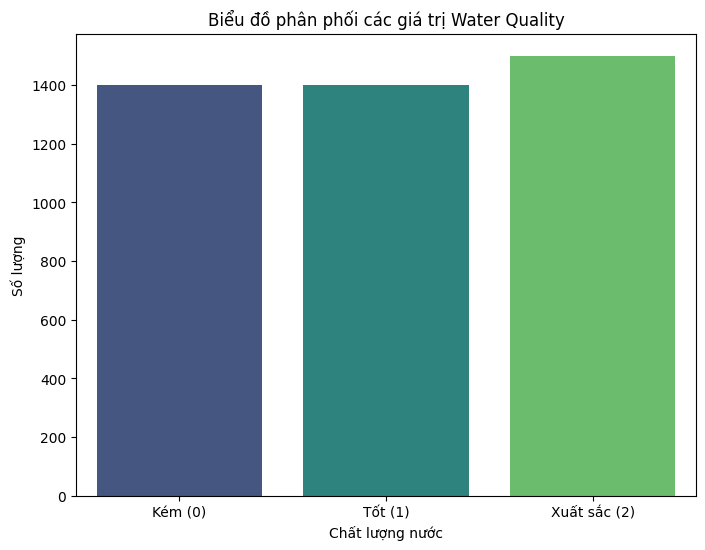

In [18]:
import matplotlib.pyplot as plt
# Vẽ biểu đồ thanh đếm số lượng cho từng giá trị trong cột 'Water Quality'
plt.figure(figsize=(8, 6))
sns.countplot(x='Water Quality', data=df, palette='viridis')
plt.title('Biểu đồ phân phối các giá trị Water Quality')
plt.xlabel('Chất lượng nước')
plt.ylabel('Số lượng')
plt.xticks(ticks=[0, 1, 2], labels=['Kém (0)', 'Tốt (1)', 'Xuất sắc (2)'])
plt.show()

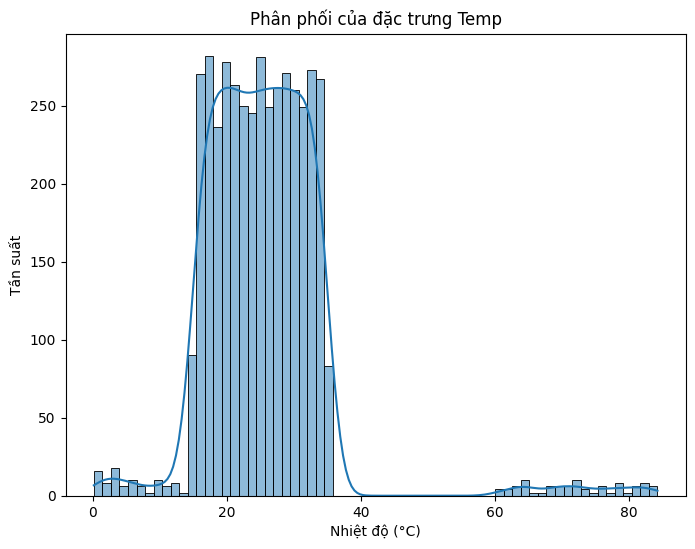

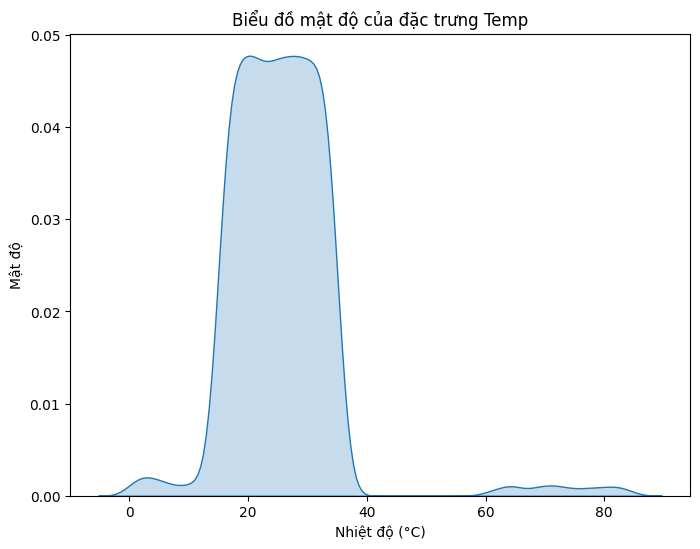

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ histogram cho đặc trưng 'Temp'
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Temp', kde=True) # kde=True để thêm đường cong mật độ ước tính
plt.title('Phân phối của đặc trưng Temp')
plt.xlabel('Nhiệt độ (°C)')
plt.ylabel('Tần suất')
plt.show()

# Vẽ biểu đồ mật độ cho đặc trưng 'Temp'
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='Temp', fill=True)
plt.title('Biểu đồ mật độ của đặc trưng Temp')
plt.xlabel('Nhiệt độ (°C)')
plt.ylabel('Mật độ')
plt.show()

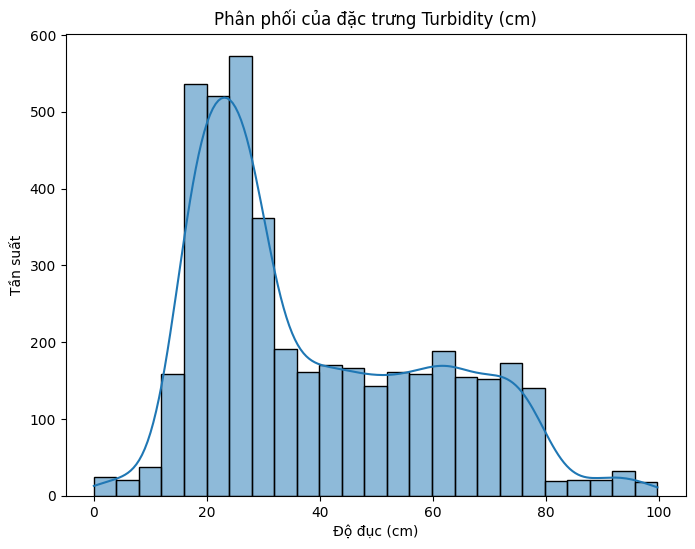

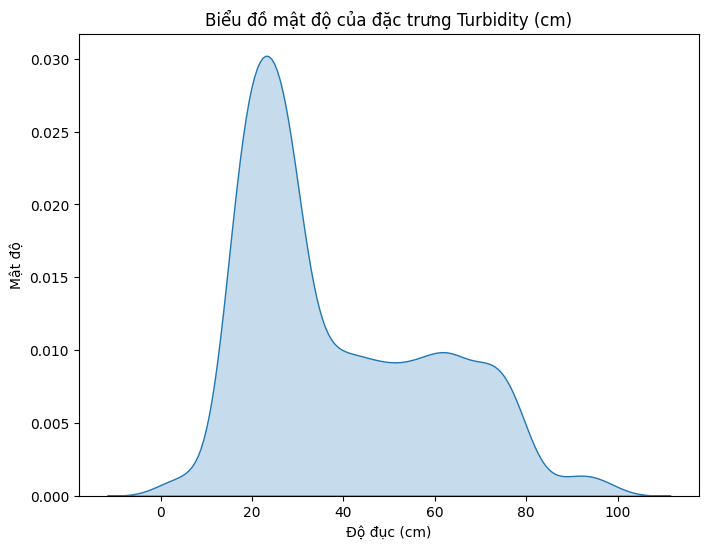

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ histogram cho đặc trưng 'Turbidity (cm)'
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Turbidity (cm)', kde=True) # kde=True để thêm đường cong mật độ ước tính
plt.title('Phân phối của đặc trưng Turbidity (cm)')
plt.xlabel('Độ đục (cm)')
plt.ylabel('Tần suất')
plt.show()

# Vẽ biểu đồ mật độ cho đặc trưng 'Turbidity (cm)'
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='Turbidity (cm)', fill=True)
plt.title('Biểu đồ mật độ của đặc trưng Turbidity (cm)')
plt.xlabel('Độ đục (cm)')
plt.ylabel('Mật độ')
plt.show()

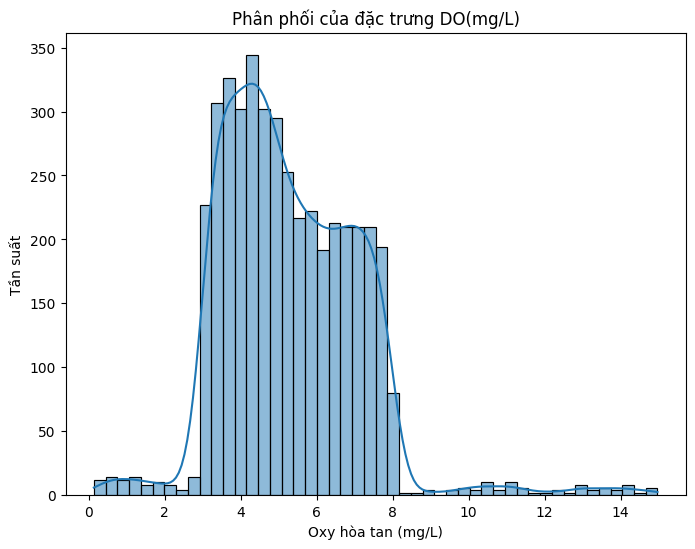

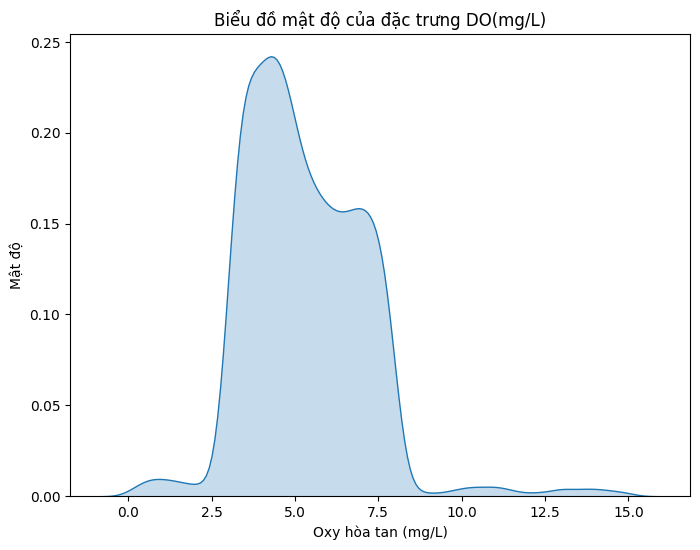

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ histogram cho đặc trưng 'DO(mg/L)'
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='DO(mg/L)', kde=True) # kde=True để thêm đường cong mật độ ước tính
plt.title('Phân phối của đặc trưng DO(mg/L)')
plt.xlabel('Oxy hòa tan (mg/L)')
plt.ylabel('Tần suất')
plt.show()

# Vẽ biểu đồ mật độ cho đặc trưng 'DO(mg/L)'
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='DO(mg/L)', fill=True)
plt.title('Biểu đồ mật độ của đặc trưng DO(mg/L)')
plt.xlabel('Oxy hòa tan (mg/L)')
plt.ylabel('Mật độ')
plt.show()

Nhận xét:

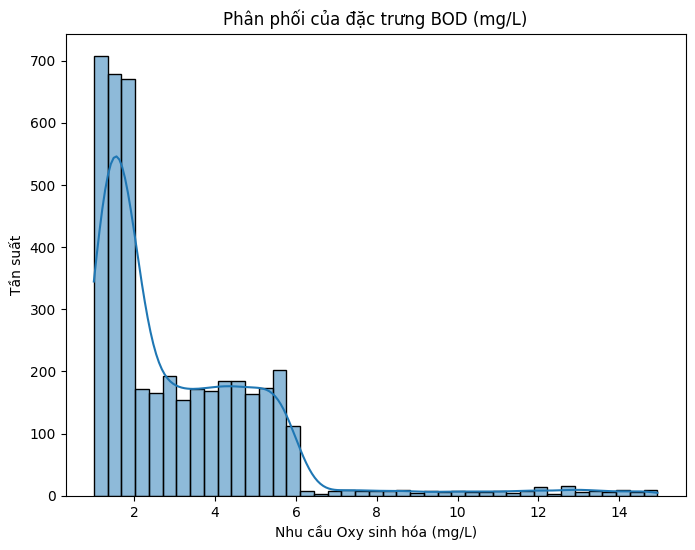

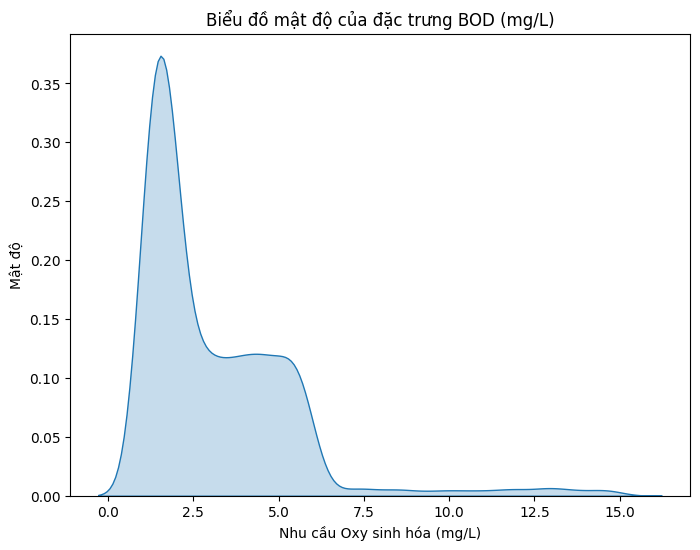

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ histogram cho đặc trưng 'BOD (mg/L)'
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='BOD (mg/L)', kde=True) # kde=True để thêm đường cong mật độ ước tính
plt.title('Phân phối của đặc trưng BOD (mg/L)')
plt.xlabel('Nhu cầu Oxy sinh hóa (mg/L)')
plt.ylabel('Tần suất')
plt.show()

# Vẽ biểu đồ mật độ cho đặc trưng 'BOD (mg/L)'
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='BOD (mg/L)', fill=True)
plt.title('Biểu đồ mật độ của đặc trưng BOD (mg/L)')
plt.xlabel('Nhu cầu Oxy sinh hóa (mg/L)')
plt.ylabel('Mật độ')
plt.show()

Hiểu đặc tính của đặc trưng, lý thuyết

Nhận xét phân bố

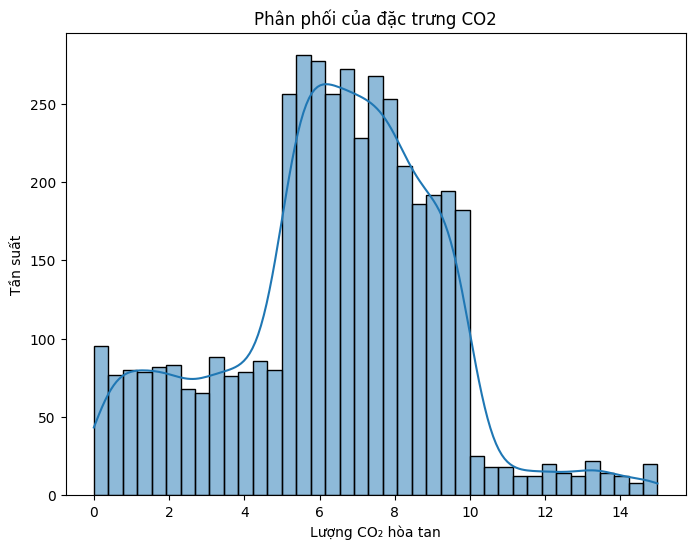

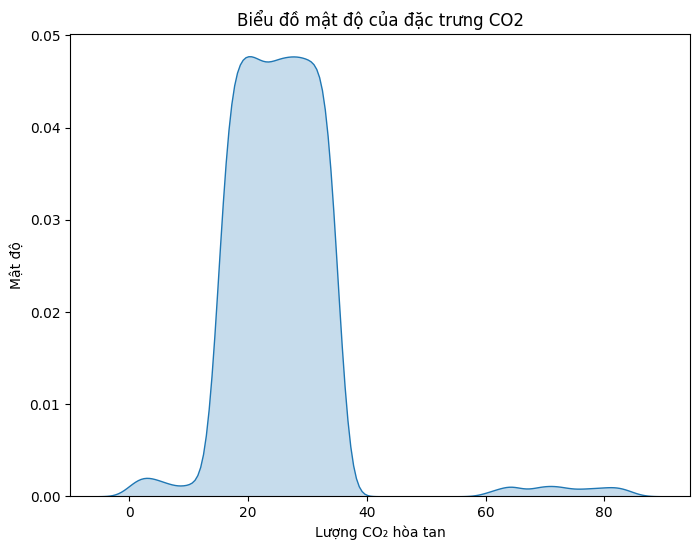

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ histogram cho đặc trưng 'CO2'
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='CO2', kde=True) # kde=True để thêm đường cong mật độ ước tính
plt.title('Phân phối của đặc trưng CO2')
plt.xlabel('Lượng CO₂ hòa tan')
plt.ylabel('Tần suất')
plt.show()

# Vẽ biểu đồ mật độ cho đặc trưng 'Temp'
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='Temp', fill=True)
plt.title('Biểu đồ mật độ của đặc trưng CO2')
plt.xlabel('Lượng CO₂ hòa tan')
plt.ylabel('Mật độ')
plt.show()

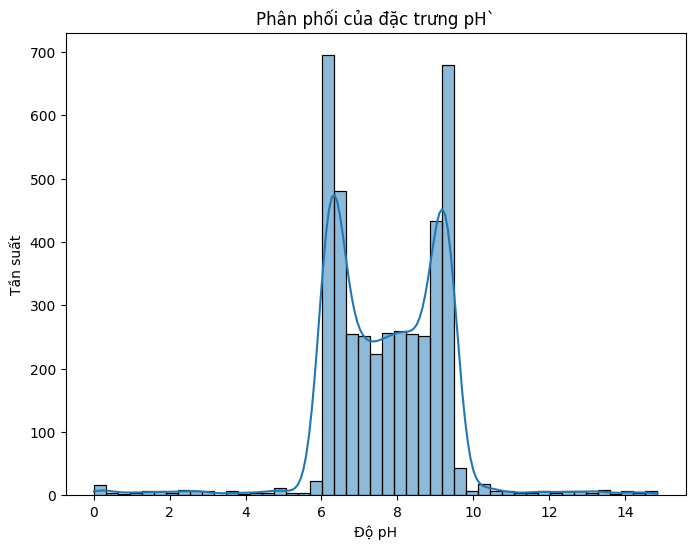

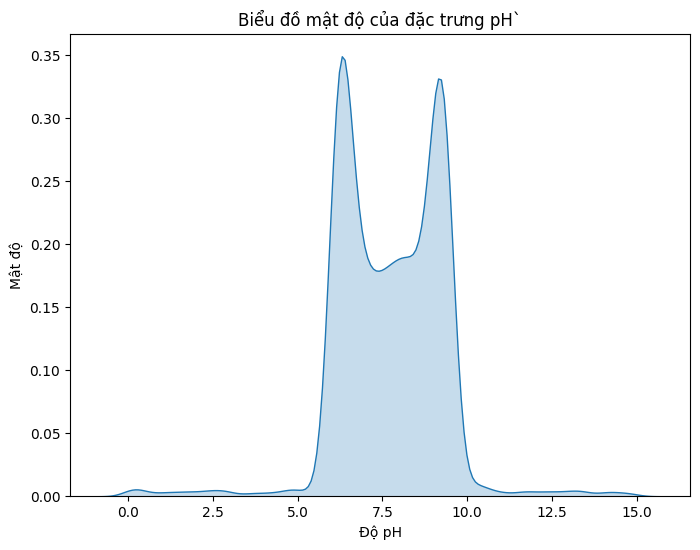

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ histogram cho đặc trưng '`pH``'
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='pH`', kde=True) # kde=True để thêm đường cong mật độ ước tính
plt.title('Phân phối của đặc trưng pH`')
plt.xlabel('Độ pH')
plt.ylabel('Tần suất')
plt.show()

# Vẽ biểu đồ mật độ cho đặc trưng '`pH``'
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='pH`', fill=True)
plt.title('Biểu đồ mật độ của đặc trưng pH`')
plt.xlabel('Độ pH')
plt.ylabel('Mật độ')
plt.show()

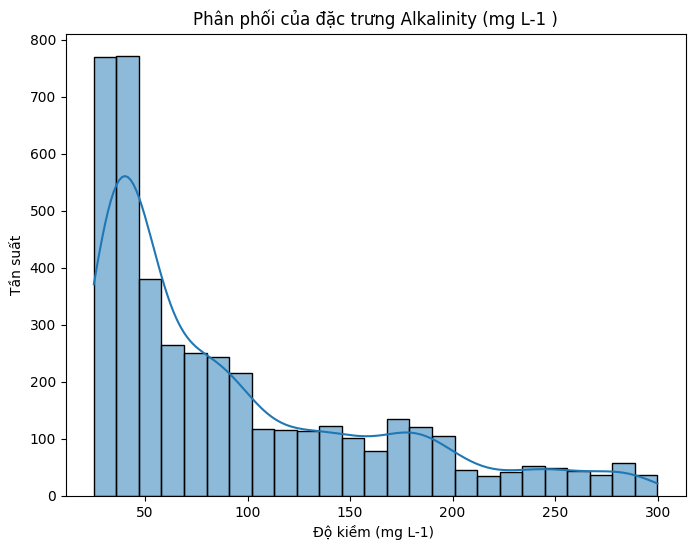

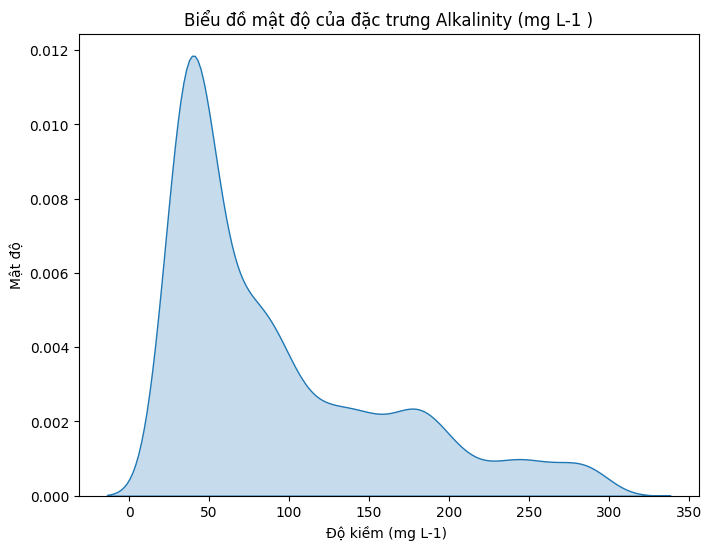

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ histogram cho đặc trưng 'Temp'
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Alkalinity (mg L-1 )', kde=True) # kde=True để thêm đường cong mật độ ước tính
plt.title('Phân phối của đặc trưng Alkalinity (mg L-1 )')
plt.xlabel('Độ kiềm (mg L-1) ')
plt.ylabel('Tần suất')
plt.show()

# Vẽ biểu đồ mật độ cho đặc trưng 'Alkalinity (mg L-1 )'
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='Alkalinity (mg L-1 )', fill=True)
plt.title('Biểu đồ mật độ của đặc trưng Alkalinity (mg L-1 )')
plt.xlabel('Độ kiềm (mg L-1) ')
plt.ylabel('Mật độ')
plt.show()

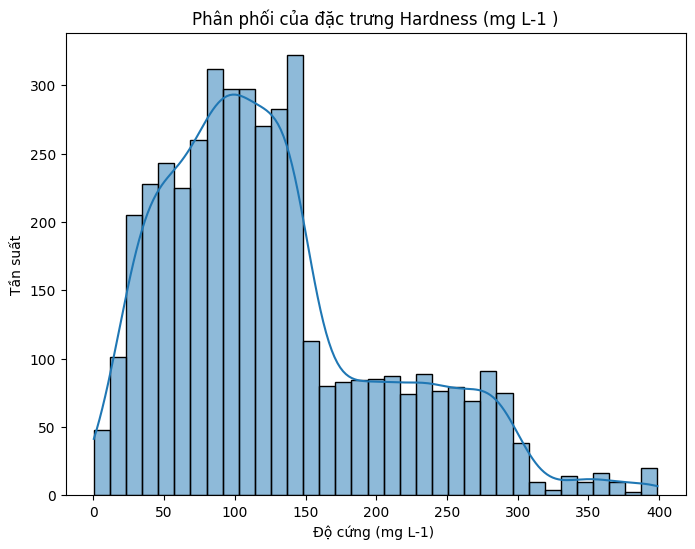

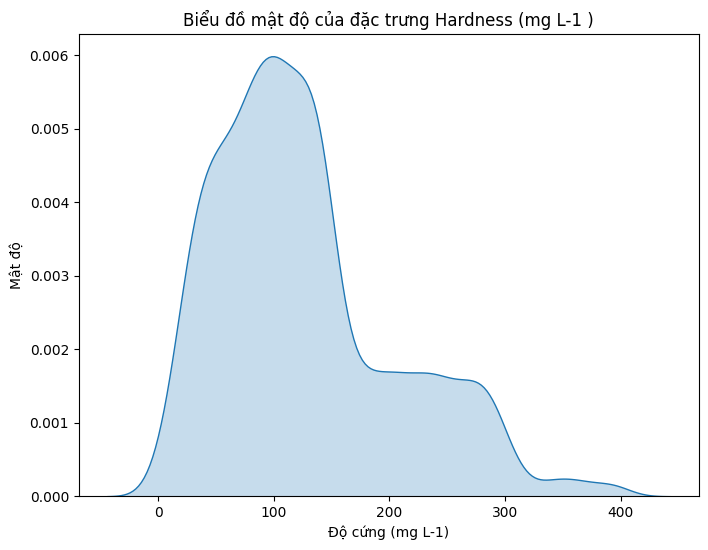

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ histogram cho đặc trưng 'Temp'
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Hardness (mg L-1 )', kde=True) # kde=True để thêm đường cong mật độ ước tính
plt.title('Phân phối của đặc trưng Hardness (mg L-1 )')
plt.xlabel('Độ cứng (mg L-1) ')
plt.ylabel('Tần suất')
plt.show()

# Vẽ biểu đồ mật độ cho đặc trưng 'Hardness (mg L-1 )'
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='Hardness (mg L-1 )', fill=True)
plt.title('Biểu đồ mật độ của đặc trưng Hardness (mg L-1 )')
plt.xlabel('Độ cứng (mg L-1)')
plt.ylabel('Mật độ')
plt.show()

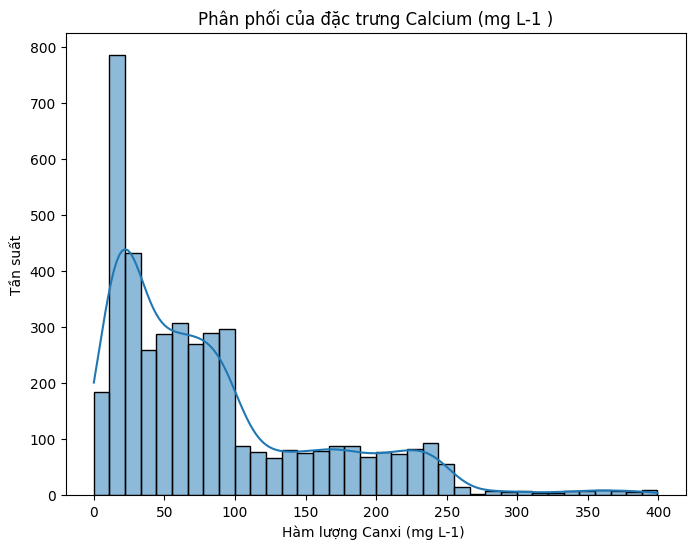

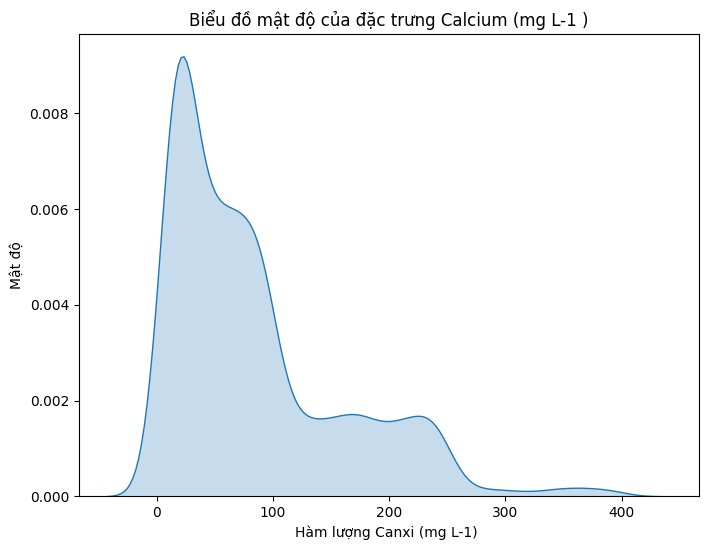

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ histogram cho đặc trưng 'Calcium (mg L-1 )'
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Calcium (mg L-1 )', kde=True) # kde=True để thêm đường cong mật độ ước tính
plt.title('Phân phối của đặc trưng Calcium (mg L-1 )')
plt.xlabel('Hàm lượng Canxi (mg L-1) ')
plt.ylabel('Tần suất')
plt.show()

# Vẽ biểu đồ mật độ cho đặc trưng 'Calcium (mg L-1 )'
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='Calcium (mg L-1 )', fill=True)
plt.title('Biểu đồ mật độ của đặc trưng Calcium (mg L-1 )')
plt.xlabel('Hàm lượng Canxi (mg L-1) ')
plt.ylabel('Mật độ')
plt.show()

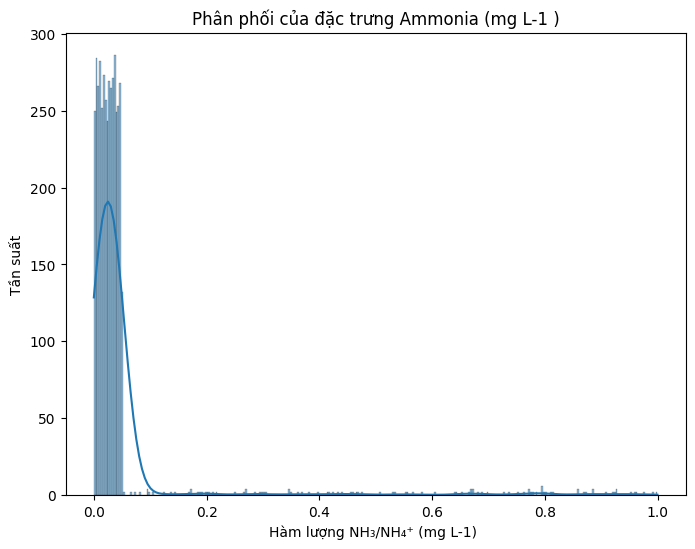

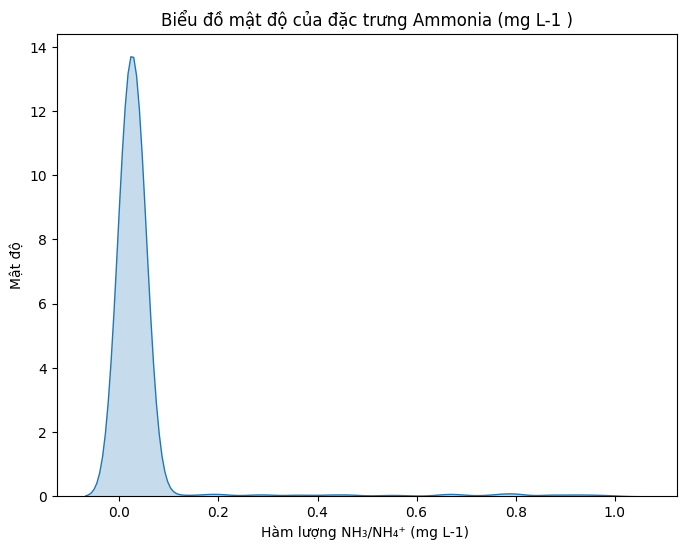

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ histogram cho đặc trưng 'Ammonia (mg L-1 )'
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Ammonia (mg L-1 )', kde=True) # kde=True để thêm đường cong mật độ ước tính
plt.title('Phân phối của đặc trưng Ammonia (mg L-1 )')
plt.xlabel('Hàm lượng NH₃/NH₄⁺ (mg L-1) ')
plt.ylabel('Tần suất')
plt.show()

# Vẽ biểu đồ mật độ cho đặc trưng 'Ammonia (mg L-1 )'
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='Ammonia (mg L-1 )', fill=True)
plt.title('Biểu đồ mật độ của đặc trưng Ammonia (mg L-1 )')
plt.xlabel('Hàm lượng NH₃/NH₄⁺ (mg L-1) ')
plt.ylabel('Mật độ')
plt.show()

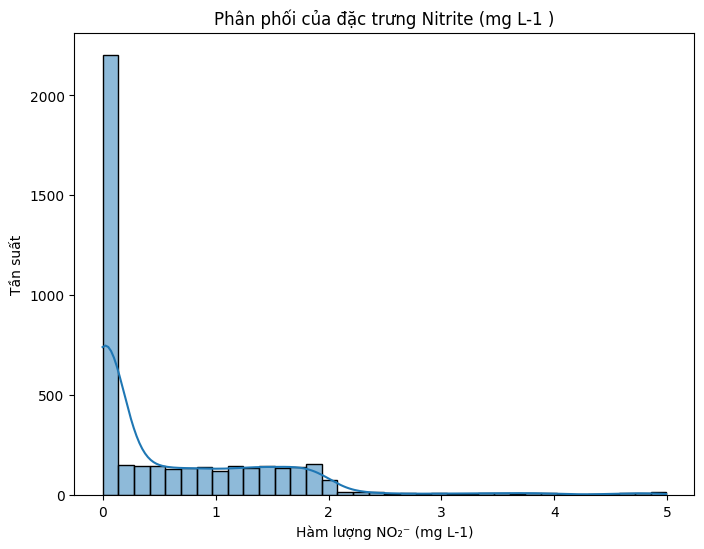

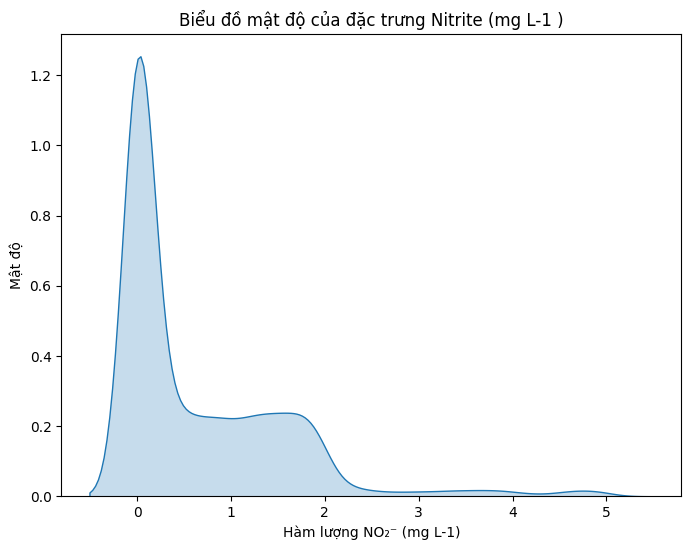

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ histogram cho đặc trưng 'Nitrite (mg L-1 )'
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Nitrite (mg L-1 )', kde=True) # kde=True để thêm đường cong mật độ ước tính
plt.title('Phân phối của đặc trưng Nitrite (mg L-1 )')
plt.xlabel('Hàm lượng NO₂⁻ (mg L-1)')
plt.ylabel('Tần suất')
plt.show()

# Vẽ biểu đồ mật độ cho đặc trưng 'Nitrite (mg L-1 )'
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='Nitrite (mg L-1 )', fill=True)
plt.title('Biểu đồ mật độ của đặc trưng Nitrite (mg L-1 )')
plt.xlabel('Hàm lượng NO₂⁻ (mg L-1)')
plt.ylabel('Mật độ')
plt.show()

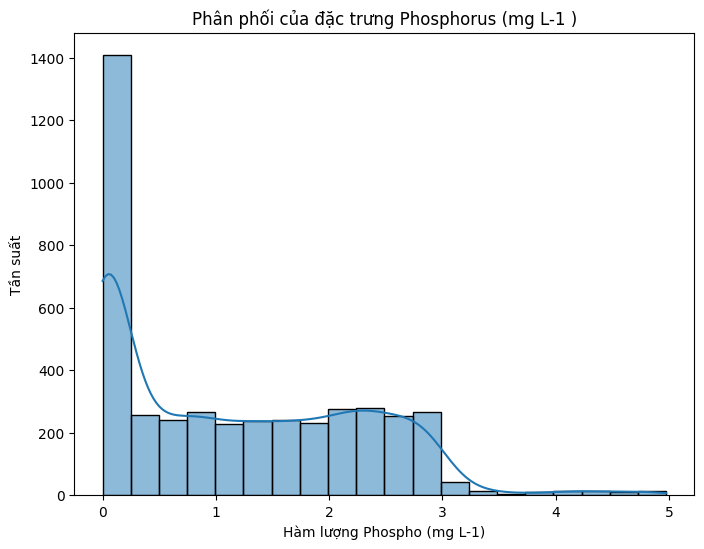

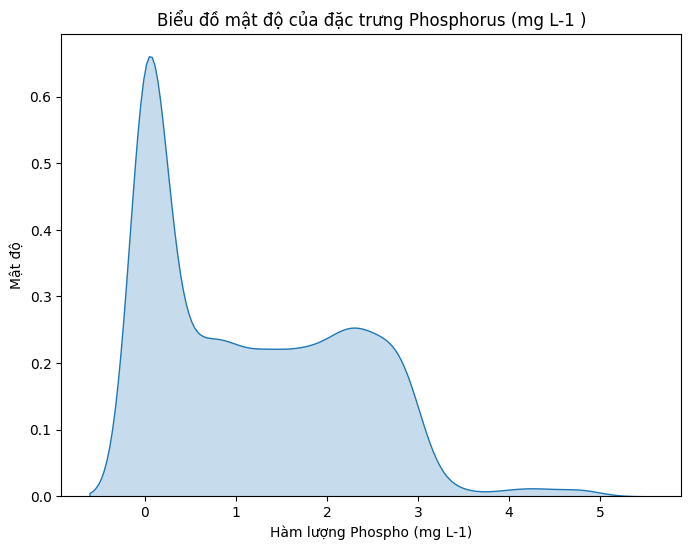

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ histogram cho đặc trưng 'Phosphorus (mg L-1 )'
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Phosphorus (mg L-1 )', kde=True) # kde=True để thêm đường cong mật độ ước tính
plt.title('Phân phối của đặc trưng Phosphorus (mg L-1 )')
plt.xlabel('Hàm lượng Phospho (mg L-1)')
plt.ylabel('Tần suất')
plt.show()

# Vẽ biểu đồ mật độ cho đặc trưng 'Phosphorus (mg L-1 )'
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='Phosphorus (mg L-1 )', fill=True)
plt.title('Biểu đồ mật độ của đặc trưng Phosphorus (mg L-1 )')
plt.xlabel('Hàm lượng Phospho (mg L-1)')
plt.ylabel('Mật độ')
plt.show()

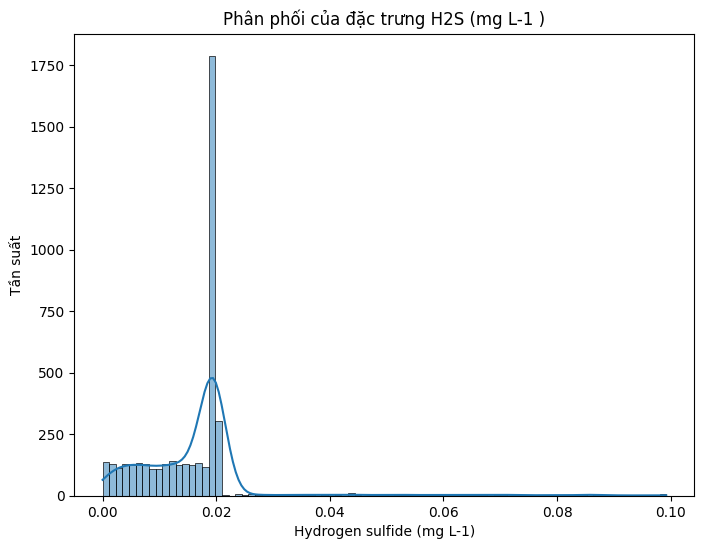

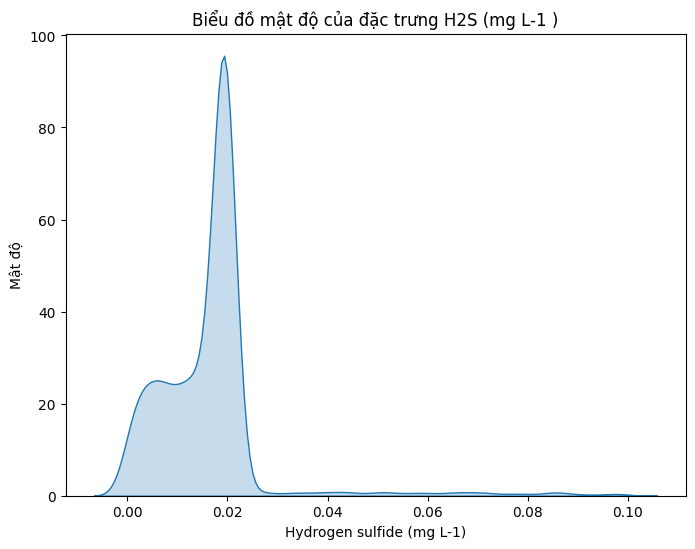

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ histogram cho đặc trưng 'H2S (mg L-1 )'
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='H2S (mg L-1 )', kde=True) # kde=True để thêm đường cong mật độ ước tính
plt.title('Phân phối của đặc trưng H2S (mg L-1 )')
plt.xlabel('Hydrogen sulfide (mg L-1)')
plt.ylabel('Tần suất')
plt.show()

# Vẽ biểu đồ mật độ cho đặc trưng 'H2S (mg L-1 )'
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='H2S (mg L-1 )', fill=True)
plt.title('Biểu đồ mật độ của đặc trưng H2S (mg L-1 )')
plt.xlabel('Hydrogen sulfide (mg L-1)')
plt.ylabel('Mật độ')
plt.show()

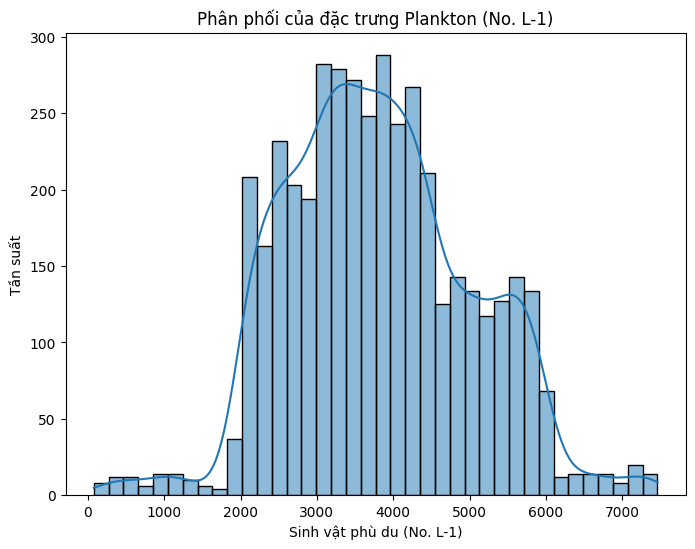

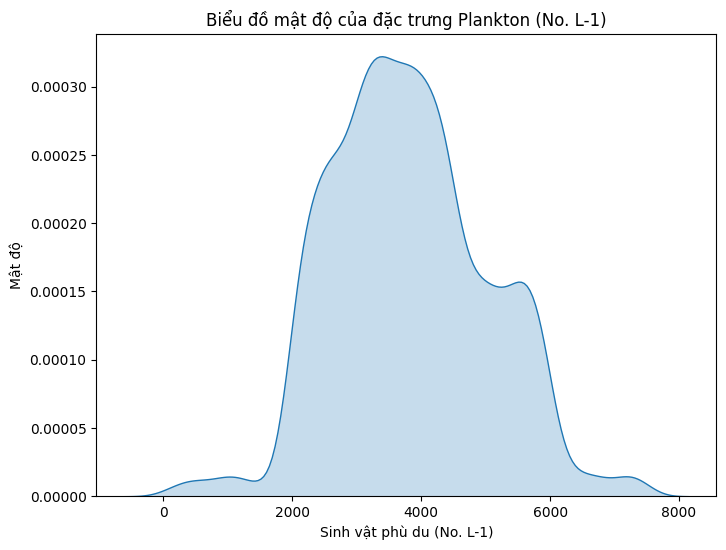

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ histogram cho đặc trưng 'Plankton (No. L-1)'
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Plankton (No. L-1)', kde=True) # kde=True để thêm đường cong mật độ ước tính
plt.title('Phân phối của đặc trưng Plankton (No. L-1)')
plt.xlabel('Sinh vật phù du (No. L-1)')
plt.ylabel('Tần suất')
plt.show()

# Vẽ biểu đồ mật độ cho đặc trưng 'Plankton (No. L-1)'
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='Plankton (No. L-1)', fill=True)
plt.title('Biểu đồ mật độ của đặc trưng Plankton (No. L-1)')
plt.xlabel('Sinh vật phù du (No. L-1)')
plt.ylabel('Mật độ')
plt.show()

### **Tìm kiếm Outlier**

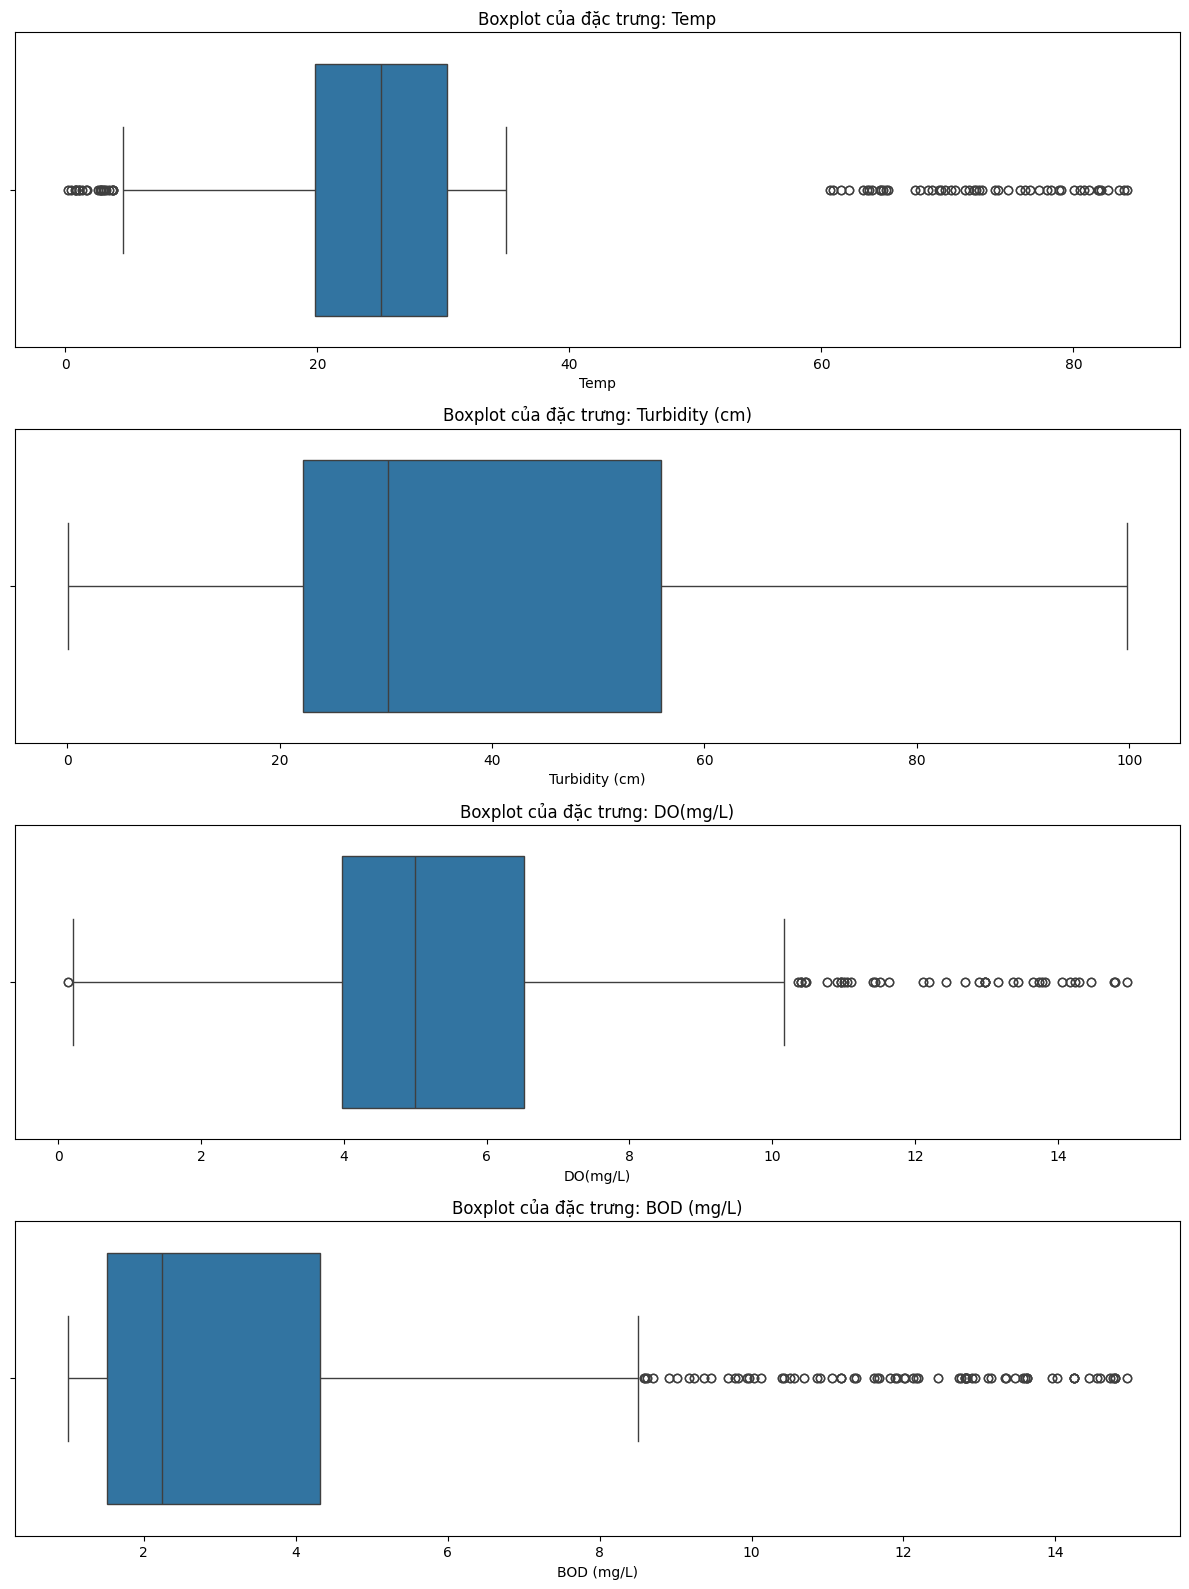

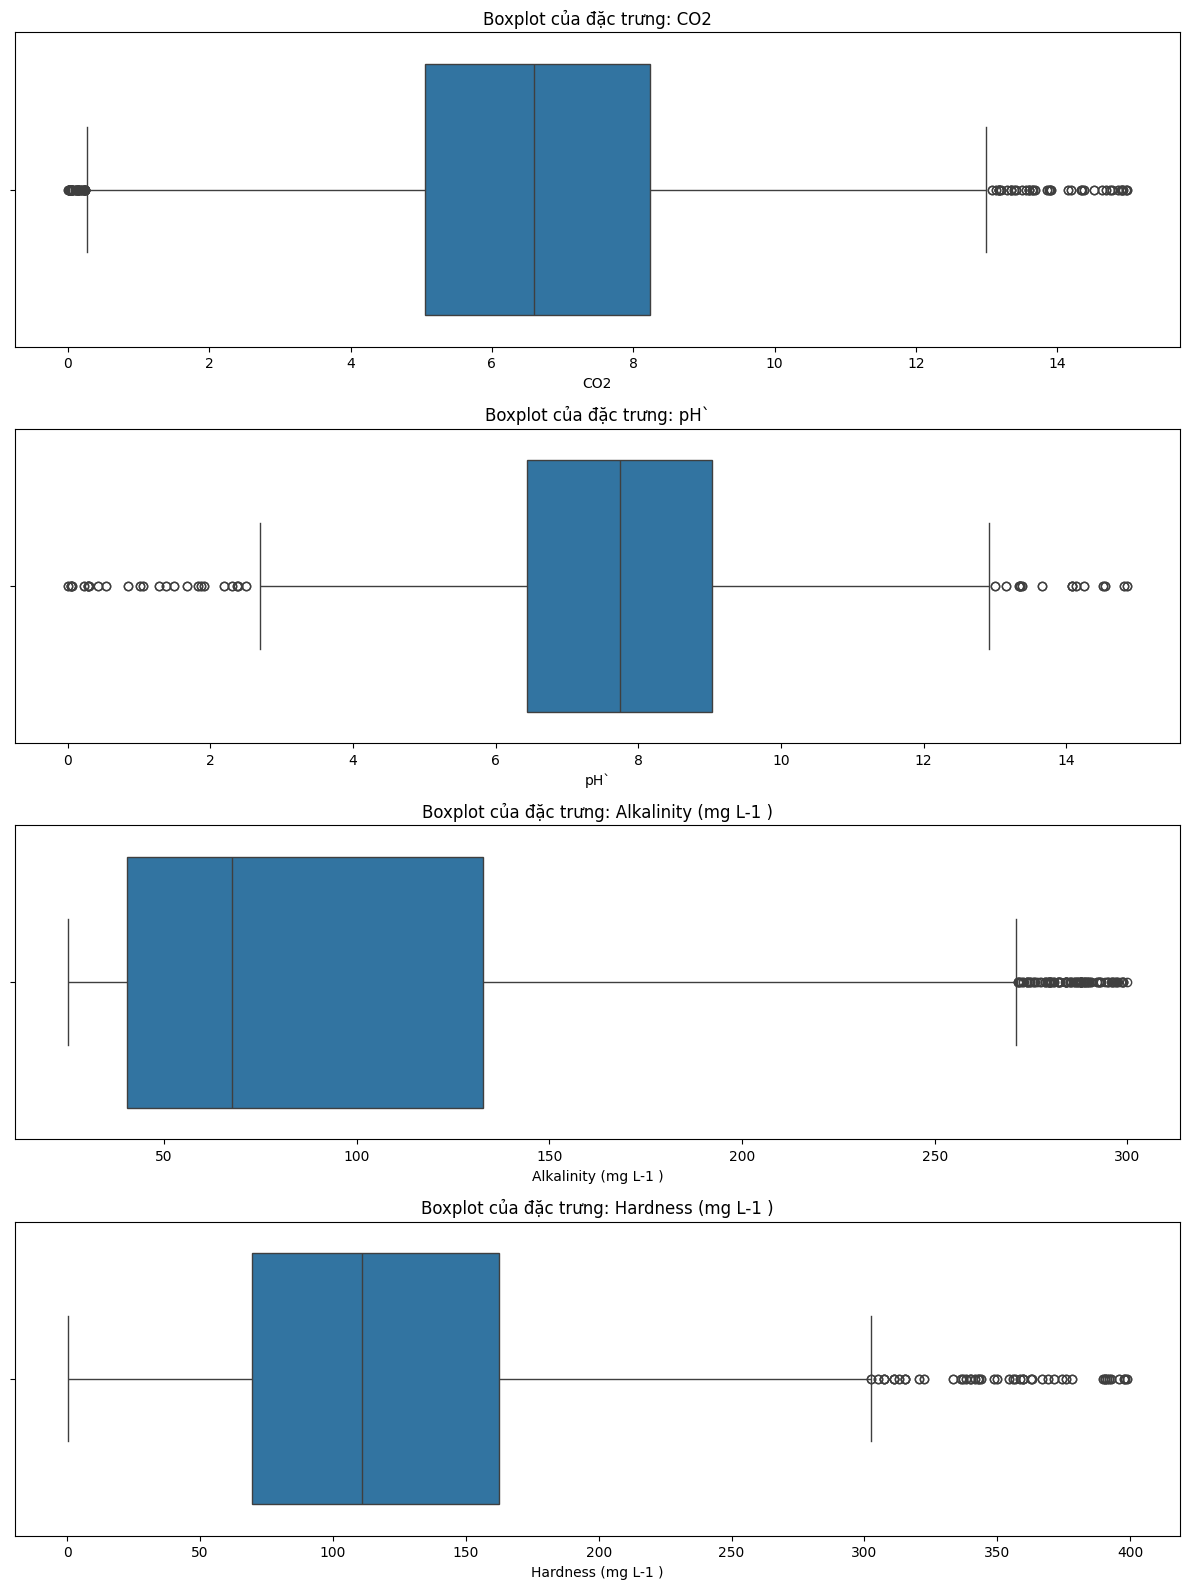

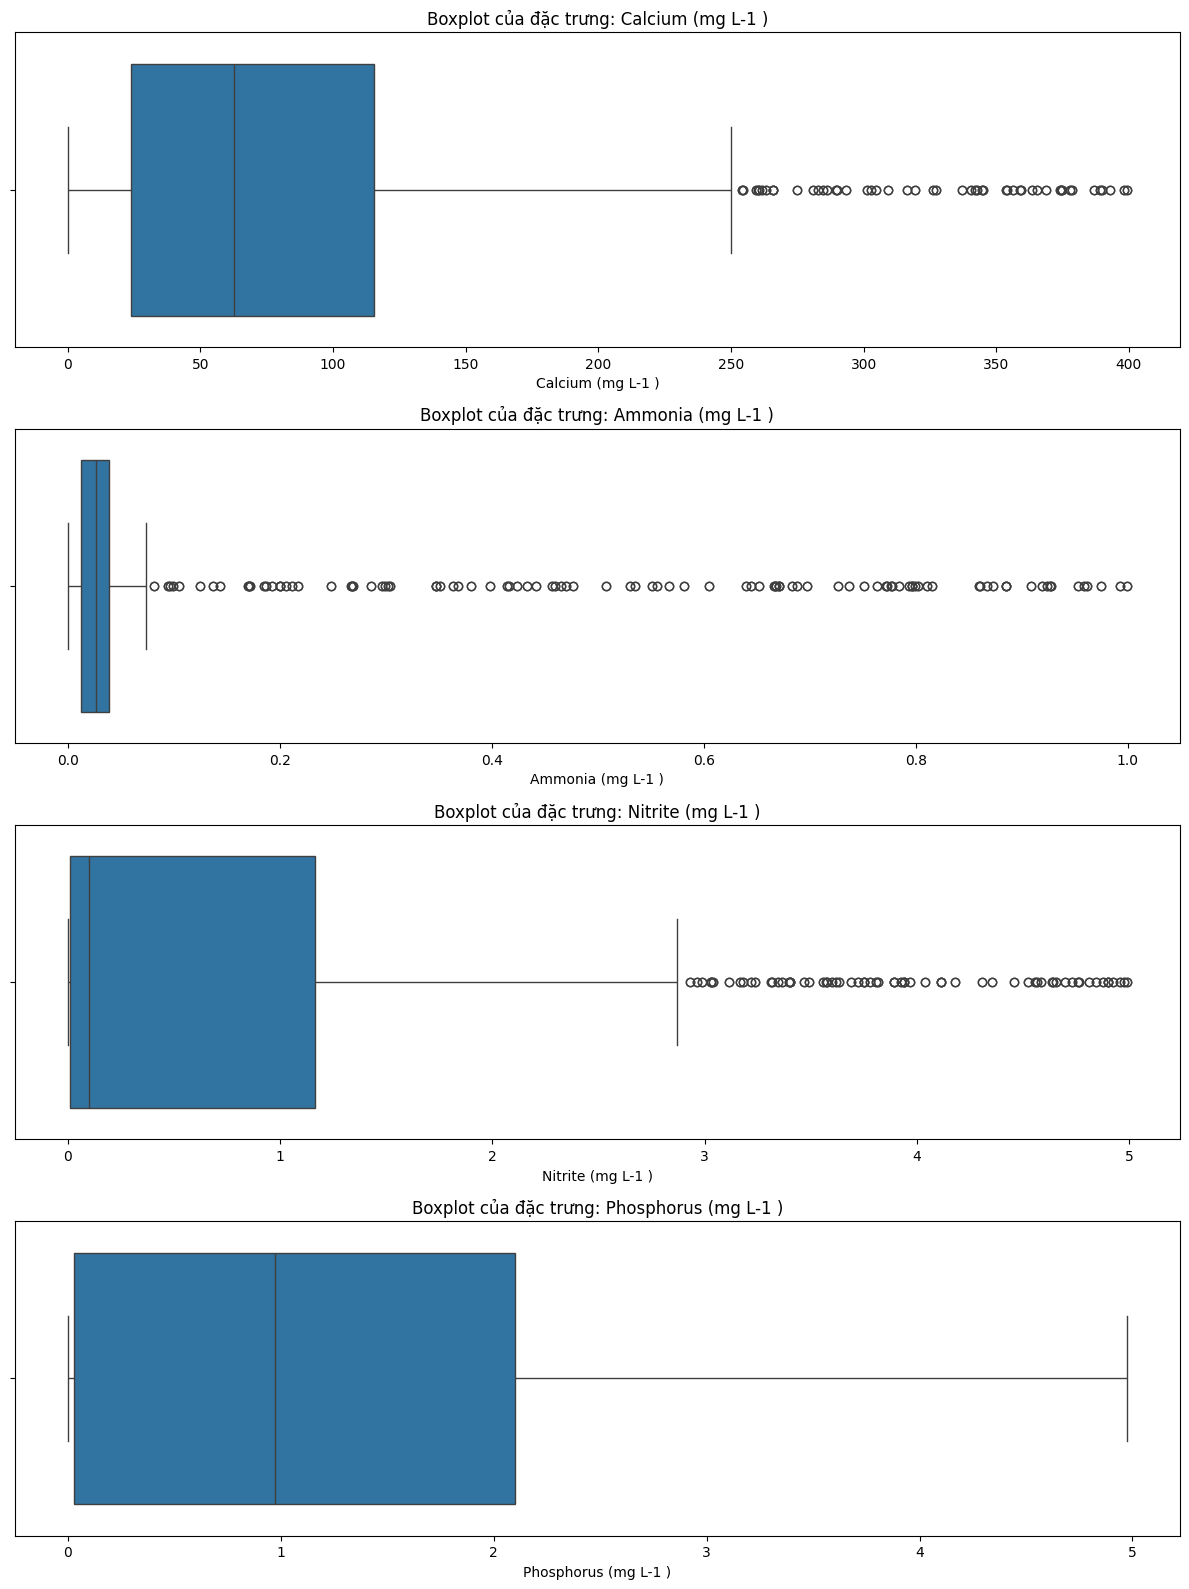

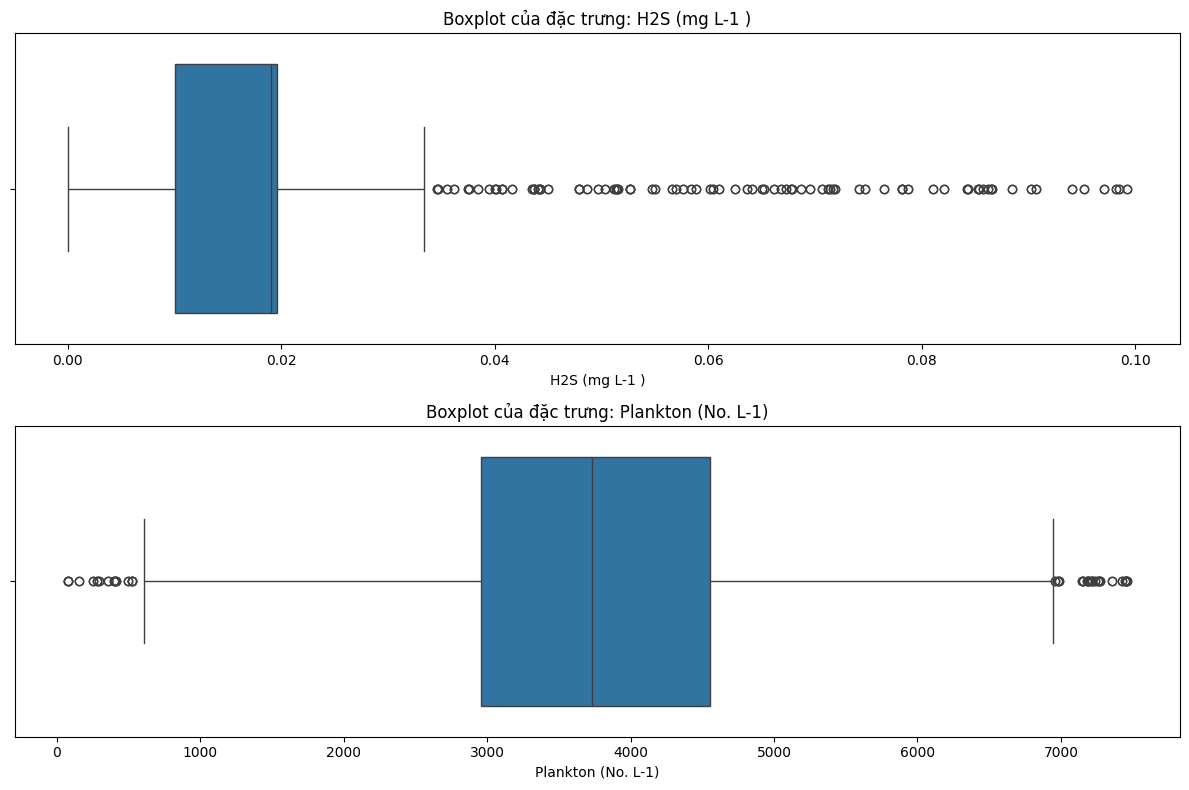

In [33]:
import matplotlib.pyplot as plt
# Lấy tên các cột đặc trưng (loại bỏ cột mục tiêu 'Water Quality')
feature_cols = df.columns.tolist()
feature_cols.remove('Water Quality')

# Số lượng đặc trưng cần vẽ trên mỗi hình
features_per_plot = 4

# Tổng số đặc trưng
num_features = len(feature_cols)

# Tính số lượng hình cần vẽ
num_plots = (num_features + features_per_plot - 1) // features_per_plot

# Vẽ boxplot cho từng nhóm đặc trưng
for i in range(num_plots):
    start_index = i * features_per_plot
    end_index = min(start_index + features_per_plot, num_features)
    current_features = feature_cols[start_index:end_index]

    # Tạo subplot với số lượng hàng tương ứng với số đặc trưng trong nhóm
    # Kích thước hình có thể điều chỉnh để phù hợp
    plt.figure(figsize=(12, 4 * len(current_features)))

    for j, feature in enumerate(current_features):
        plt.subplot(len(current_features), 1, j + 1)
        sns.boxplot(x=df[feature])
        plt.title(f'Boxplot của đặc trưng: {feature}')
        plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

### **Mối quan hệ giữa các đặc trưng**

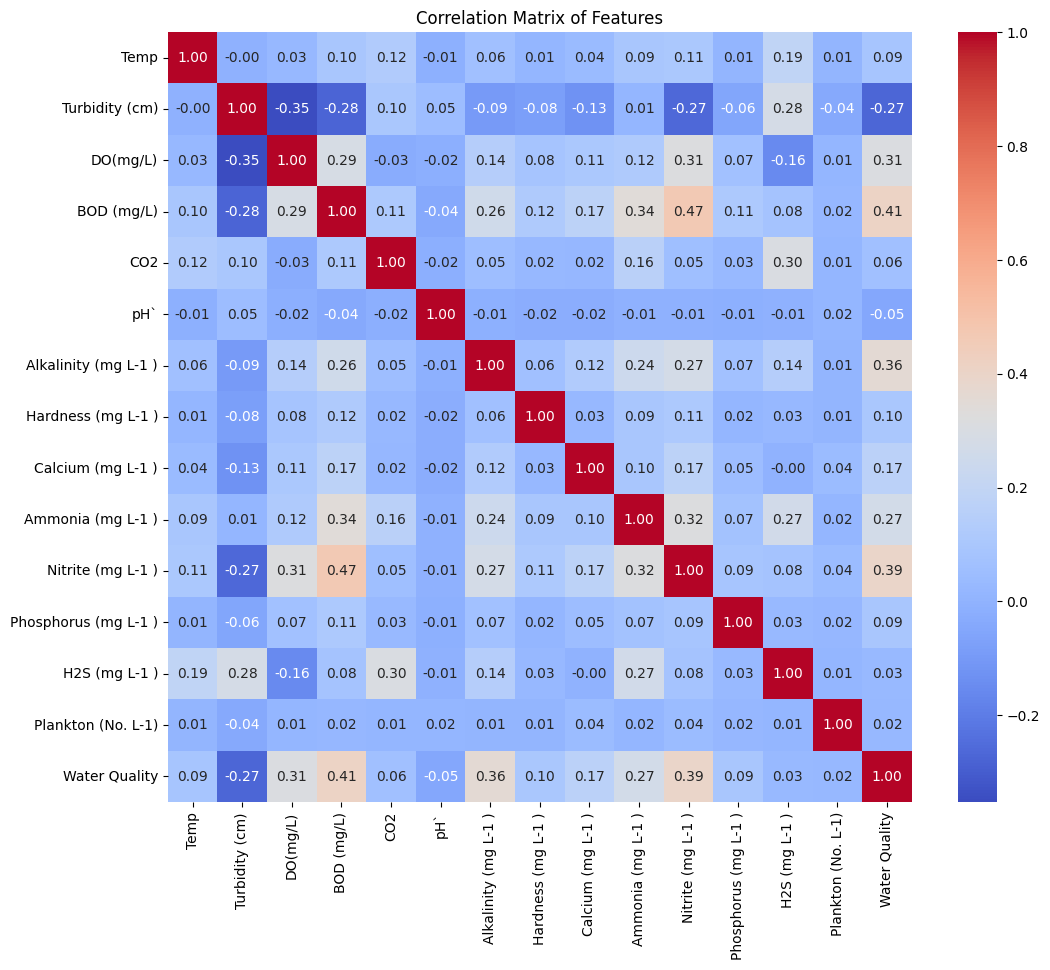

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()


## **Tiền xử lý dl**

Làm sạch dữ liệu: Loại bỏ, điền giá trị thiếu.

Mã hóa

chuẩn hóa/chuẩn chỉnh

chia dữ liệu

### **Xử lý Outlier**

Chọn đặc trưng quan trọng cho mô hình

Đã áp dụng Winsorizing cho cột: Temp
Đã áp dụng Winsorizing cho cột: CO2
Đã áp dụng Winsorizing cho cột: pH`
Đã áp dụng Winsorizing cho cột: Hardness (mg L-1 )
Đã áp dụng Winsorizing cho cột: Calcium (mg L-1 )
Đã áp dụng Winsorizing cho cột: H2S (mg L-1 )
Đã áp dụng Winsorizing cho cột: Plankton (No. L-1)

Boxplots sau khi áp dụng Winsorizing:


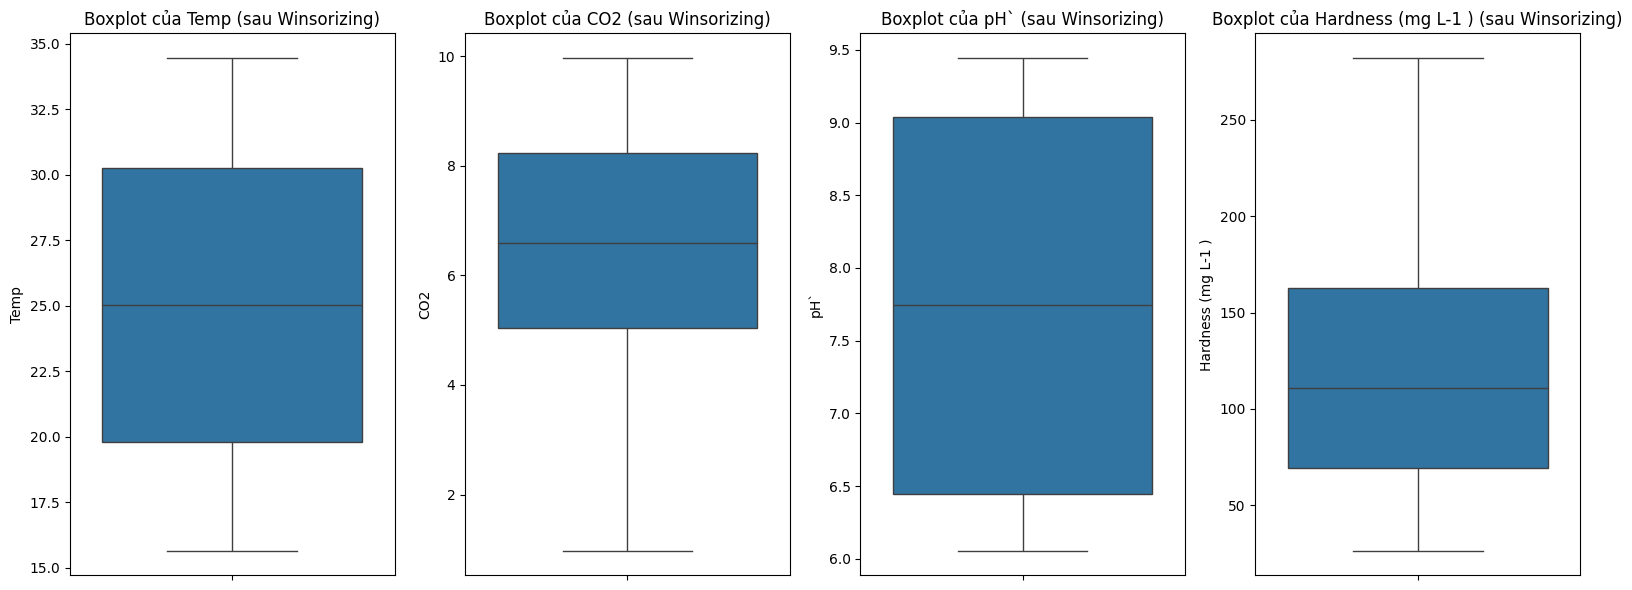

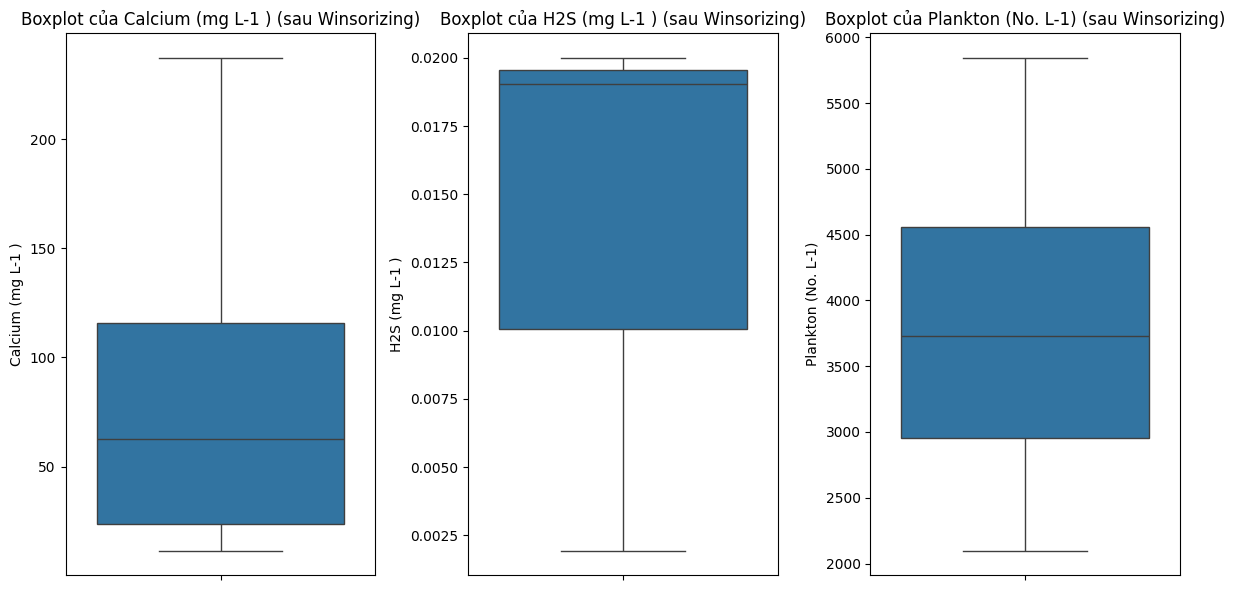

In [35]:
# ### **Xử lý Outlier (Winsorizing)**
from scipy.stats.mstats import winsorize

# Danh sách các cột có thể áp dụng winsorizing (dựa trên phân tích boxplot)
columns_to_winsorize = [
    'Temp', 'CO2', 'pH`', 'Hardness (mg L-1 )', 'Calcium (mg L-1 )',
    'H2S (mg L-1 )', 'Plankton (No. L-1)'
]

# Áp dụng winsorizing cho từng cột
# Giới hạn (limit) 0.05 cho cả hai phía có nghĩa là 5% giá trị nhỏ nhất và 5% giá trị lớn nhất sẽ được winsorized

for col in columns_to_winsorize:
    try:
        # Áp dụng winsorize. limit là một tuple (lower, upper)
        df[col] = winsorize(df[col], limits=[0.05, 0.05])
        print(f"Đã áp dụng Winsorizing cho cột: {col}")
    except Exception as e:
        print(f"Không thể áp dụng Winsorizing cho cột {col}: {e}")

# Sau khi Winsorizing, vẽ lại boxplot cho một vài cột để kiểm tra
print("\nBoxplots sau khi áp dụng Winsorizing:")
selected_features_after_winsorize = ['Temp', 'CO2', 'pH`', 'Hardness (mg L-1 )', 'Calcium (mg L-1 )',
    'H2S (mg L-1 )', 'Plankton (No. L-1)']
# Số lượng đặc trưng cần vẽ trong mỗi hình (giữ nguyên như trước)
features_per_plot = 4

# Tính toán số lượng hình cần vẽ
num_plots_after = (len(selected_features_after_winsorize) + features_per_plot - 1) // features_per_plot


# Vòng lặp để vẽ từng nhóm đặc trưng sau winsorizing
for i in range(num_plots_after):
  start_index = i * features_per_plot
  end_index = min((i + 1) * features_per_plot, len(selected_features_after_winsorize))
  current_features = selected_features_after_winsorize[start_index:end_index]

  # Tạo hình và các axes
  fig, axes = plt.subplots(1, len(current_features), figsize=(4 * len(current_features), 6))

  # Nếu chỉ có 1 đặc trưng trong nhóm, axes không phải là mảng
  if len(current_features) == 1:
    axes = [axes]

  # Vòng lặp để vẽ boxplot cho từng đặc trưng trong nhóm hiện tại
  for j, feature in enumerate(current_features):
    sns.boxplot(y=df[feature], ax=axes[j]) # Sử dụng DataFrame 'df' đã được winsorized
    axes[j].set_title(f'Boxplot của {feature} (sau Winsorizing)')
    axes[j].set_ylabel(feature) # Đặt tên trục y là tên đặc trưng

  # Điều chỉnh khoảng cách giữa các subplot
  plt.tight_layout()
  plt.show()


### **Trích xuất đặc trưng**

In [36]:

# ### **Trích xuất đặc trưng**
# Tính tỷ lệ BOD/DO
df['BOD_DO_Ratio'] = df['BOD (mg/L)'] / (df['DO(mg/L)'] + 1e-9) # Cộng thêm một lượng nhỏ để tránh chia cho 0

# Tính tỷ lệ Nitrite/Ammonia (chỉ số oxy hóa nitơ)
df['Nitrite_Ammonia_Ratio'] = df['Nitrite (mg L-1 )'] / (df['Ammonia (mg L-1 )'] + 1e-9)

# Tính chỉ số tổng dinh dưỡng (Nitrite + Phosphorus)
df['Total_Nutrients'] = df['Nitrite (mg L-1 )'] + df['Phosphorus (mg L-1 )']

# In thông tin về các đặc trưng mới
print(df[['BOD_DO_Ratio', 'Nitrite_Ammonia_Ratio', 'Total_Nutrients']].head())

   BOD_DO_Ratio  Nitrite_Ammonia_Ratio  Total_Nutrients
0     35.904461              15.225510         4.361294
1      0.949760              22.727628         2.187659
2      1.030497               5.030020         4.908739
3      0.776030               4.036595         6.746315
4      9.792920               5.807566         8.510599


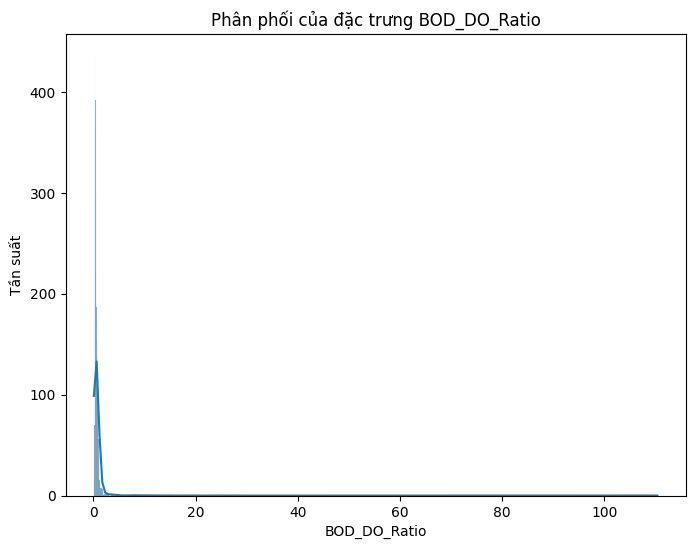

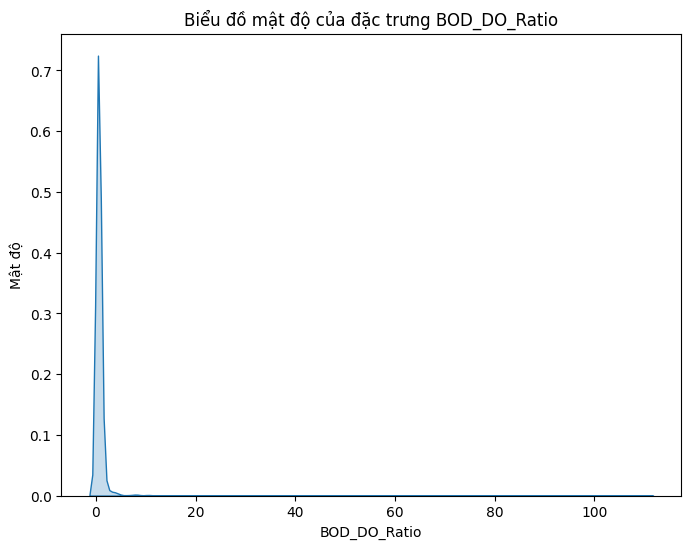

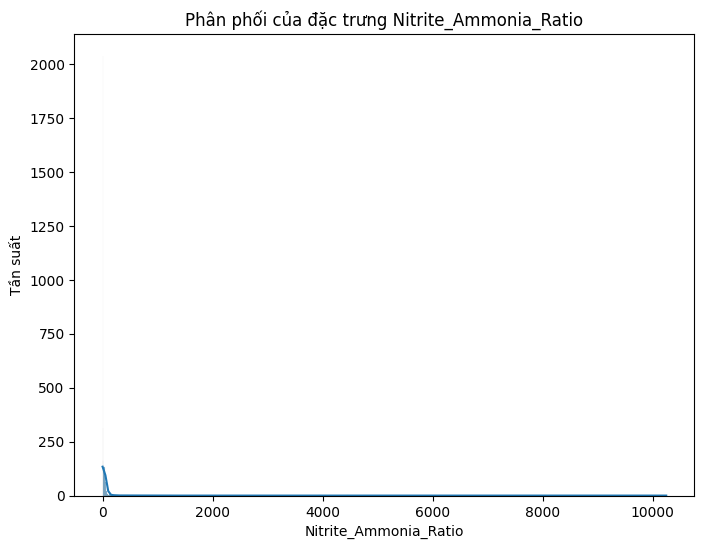

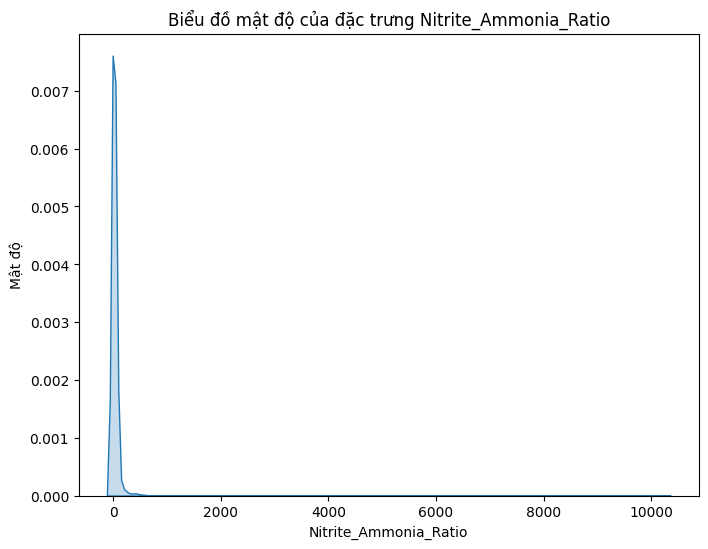

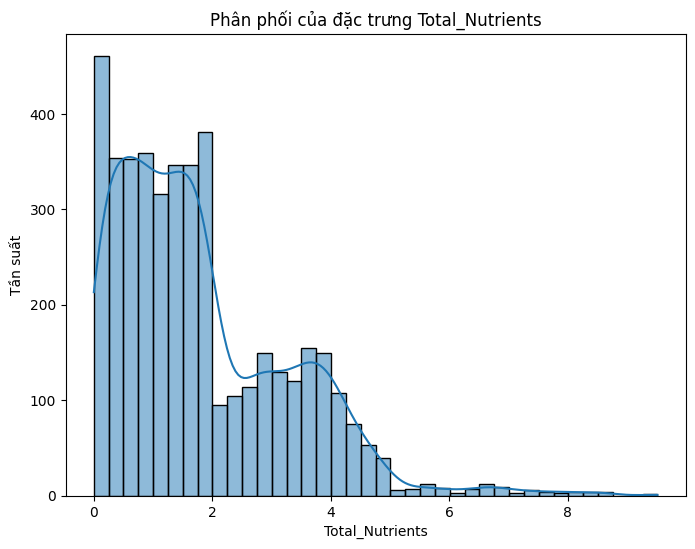

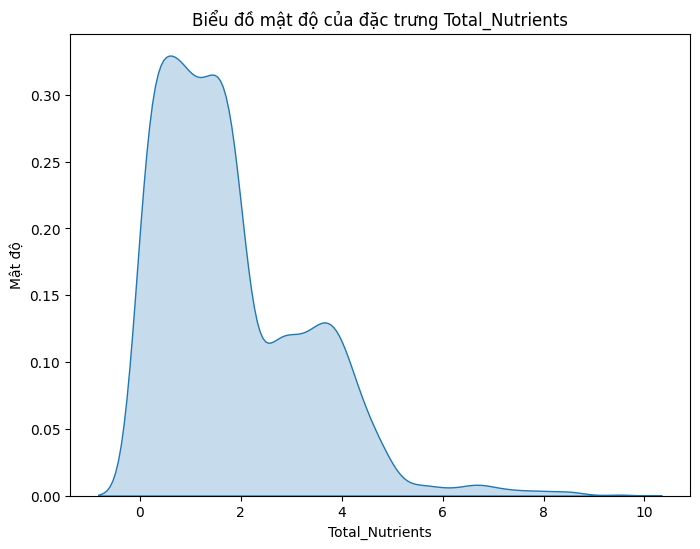

In [37]:

import matplotlib.pyplot as plt
# List các đặc trưng mới
new_features = ['BOD_DO_Ratio', 'Nitrite_Ammonia_Ratio', 'Total_Nutrients']

# Vẽ biểu đồ mật độ và tần suất cho từng đặc trưng mới
for feature in new_features:
  # Biểu đồ Histogram (tần suất)
  plt.figure(figsize=(8, 6))
  sns.histplot(data=df, x=feature, kde=True)
  plt.title(f'Phân phối của đặc trưng {feature}')
  plt.xlabel(feature)
  plt.ylabel('Tần suất')
  plt.show()

  # Biểu đồ mật độ
  plt.figure(figsize=(8, 6))
  sns.kdeplot(data=df, x=feature, fill=True)
  plt.title(f'Biểu đồ mật độ của đặc trưng {feature}')
  plt.xlabel(feature)
  plt.ylabel('Mật độ')
  plt.show()

### **Lựa chọn đặc trưng**

Tầm quan trọng của các đặc trưng (Feature Importance):
H2S (mg L-1 )            0.140673
DO(mg/L)                 0.135140
BOD (mg/L)               0.132367
Turbidity (cm)           0.125296
Nitrite (mg L-1 )        0.096324
Ammonia (mg L-1 )        0.092159
CO2                      0.062670
BOD_DO_Ratio             0.054013
Alkalinity (mg L-1 )     0.046603
Temp                     0.042051
Nitrite_Ammonia_Ratio    0.025242
Total_Nutrients          0.018186
Phosphorus (mg L-1 )     0.007055
Calcium (mg L-1 )        0.006577
pH`                      0.005879
Hardness (mg L-1 )       0.005774
Plankton (No. L-1)       0.003992
dtype: float64


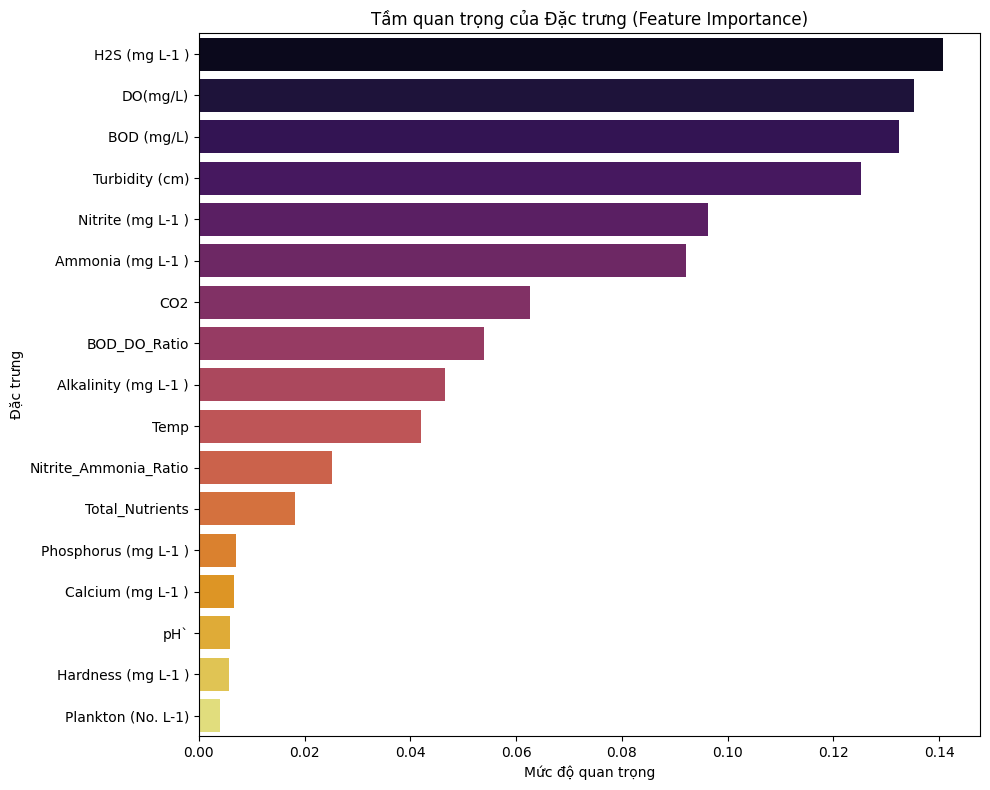


12 đặc trưng quan trọng nhất được chọn:
['H2S (mg L-1 )', 'DO(mg/L)', 'BOD (mg/L)', 'Turbidity (cm)', 'Nitrite (mg L-1 )', 'Ammonia (mg L-1 )', 'CO2', 'BOD_DO_Ratio', 'Alkalinity (mg L-1 )', 'Temp', 'Nitrite_Ammonia_Ratio', 'Total_Nutrients']

DataFrame sau khi lựa chọn đặc trưng:
   H2S (mg L-1 )   DO(mg/L)  BOD (mg/L)  Turbidity (cm)  Nitrite (mg L-1 )  \
0       0.019992   0.208153    7.473607       10.127148           4.355310   
1       0.019992  11.434463   10.859998       94.015595           2.182753   
2       0.019992  12.430865   12.809970       90.653462           4.901760   
3       0.019992  10.963529    8.508023        0.066344           3.571842   
4       0.019992   1.361736   13.335372        2.119173           4.655898   

   Ammonia (mg L-1 )       CO2  BOD_DO_Ratio  Alkalinity (mg L-1 )       Temp  \
0           0.286054  9.966002     35.904461            218.364855  34.459958   
1           0.096040  9.966002      0.949760            273.939692  34.459958   
2    

In [38]:

# ### **Lựa chọn đặc trưng (Feature Selection)**

# Loại bỏ cột mục tiêu tạm thời để thực hiện lựa chọn đặc trưng
X_features = df.drop(columns=["Water Quality"])
y_target = df["Water Quality"]

# Để lựa chọn đặc trưng dựa trên tầm quan trọng, chúng ta sẽ sử dụng một mô hình Random Forest.
# Huấn luyện một mô hình Random Forest trên toàn bộ dữ liệu (không bao gồm nhãn) để đánh giá tầm quan trọng.
# Lưu ý: Việc này khác với huấn luyện mô hình cuối cùng. Đây chỉ dùng để đánh giá đặc trưng.
from sklearn.ensemble import RandomForestClassifier

# Khởi tạo một mô hình Random Forest
# n_estimators có thể cần điều chỉnh, nhưng 100 thường là đủ để đánh giá tầm quan trọng.
# random_state để đảm bảo kết quả có thể tái lập.
feature_selection_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Huấn luyện mô hình trên dữ liệu (không nhãn)
feature_selection_model.fit(X_features, y_target)

# Lấy tầm quan trọng của từng đặc trưng
feature_importances = feature_selection_model.feature_importances_

# Tạo một Series để dễ dàng xem và sắp xếp
importance_df = pd.Series(feature_importances, index=X_features.columns)

# Sắp xếp các đặc trưng theo tầm quan trọng giảm dần
sorted_importance = importance_df.sort_values(ascending=False)

# In ra tầm quan trọng của các đặc trưng
print("Tầm quan trọng của các đặc trưng (Feature Importance):")
print(sorted_importance)

# --- Trực quan hóa tầm quan trọng của đặc trưng ---
plt.figure(figsize=(10, 8))
sns.barplot(x=sorted_importance, y=sorted_importance.index, palette='inferno')
plt.title('Tầm quan trọng của Đặc trưng (Feature Importance)')
plt.xlabel('Mức độ quan trọng')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.show()

# --- Chọn các đặc trưng quan trọng nhất ---
num_features_to_keep = 12
selected_features = sorted_importance.head(num_features_to_keep).index.tolist()

print(f"\n{num_features_to_keep} đặc trưng quan trọng nhất được chọn:")
print(selected_features)

# Cập nhật DataFrame gốc 'df' chỉ với các đặc trưng đã chọn và cột target
# Lưu ý: Đảm bảo cột 'Water Quality' vẫn còn trong df
df_selected = df[selected_features + ["Water Quality"]].copy()

print("\nDataFrame sau khi lựa chọn đặc trưng:")
print(df_selected.head())



### **Chia tập dữ liệu**

Tại sao phải chia rồi mới chuẩn hóa ?

In [39]:
# ### **Chia tập dữ liệu**

# Tách feature và target
X = df_selected.drop(columns=["Water Quality"])  # Đặc trưng
y = df_selected["Water Quality"]                 # Nhãn

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

print("Kích thước tập huấn luyện X_train:", X_train.shape)
print("Kích thước tập huấn luyện y_train:", y_train.shape)
print("Kích thước tập kiểm tra X_test:", X_test.shape)
print("Kích thước tập kiểm tra y_test:", y_test.shape)

Kích thước tập huấn luyện X_train: (3440, 12)
Kích thước tập huấn luyện y_train: (3440,)
Kích thước tập kiểm tra X_test: (860, 12)
Kích thước tập kiểm tra y_test: (860,)


### **Chuẩn hóa dữ liệu**

In [40]:
# ### **Chuẩn hóa dữ liệu**
from sklearn.preprocessing import StandardScaler
import numpy as np # Import numpy nếu chưa có

# Xác định các cột số cần chuẩn hóa
# Bao gồm cả các đặc trưng mới đã tạo
numerical_cols_to_scale = X_train.select_dtypes(include=np.number).columns
print("Các cột số cần chuẩn hóa:", numerical_cols_to_scale)

scaler = StandardScaler()

# Fit scaler chỉ trên tập huấn luyện và transform cả hai tập
X_train_scaled = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test_scaled = scaler.transform(X_test[numerical_cols_to_scale])

# Chuyển lại về DataFrame để giữ tên cột (tùy chọn nhưng hữu ích)
X_train = pd.DataFrame(X_train_scaled, columns=numerical_cols_to_scale, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=numerical_cols_to_scale, index=X_test.index)

print("\nX_train sau khi chuẩn hóa:")
print(X_train.head())
print("\nX_test sau khi chuẩn hóa:")
print(X_test.head())

Các cột số cần chuẩn hóa: Index(['H2S (mg L-1 )', 'DO(mg/L)', 'BOD (mg/L)', 'Turbidity (cm)',
       'Nitrite (mg L-1 )', 'Ammonia (mg L-1 )', 'CO2', 'BOD_DO_Ratio',
       'Alkalinity (mg L-1 )', 'Temp', 'Nitrite_Ammonia_Ratio',
       'Total_Nutrients'],
      dtype='object')

X_train sau khi chuẩn hóa:
      H2S (mg L-1 )  DO(mg/L)  BOD (mg/L)  Turbidity (cm)  Nitrite (mg L-1 )  \
4090       0.843313 -0.270846   -0.495120       -0.101090          -0.690253   
408       -1.407685  1.256804    1.874597       -0.904925           1.110918   
665        0.750435 -0.887622   -0.627763        1.905857          -0.251650   
1736      -1.439188  1.450019    1.137288       -0.576661          -0.010095   
2557      -1.503394  1.095122    0.112213       -0.866932           1.474082   

      Ammonia (mg L-1 )       CO2  BOD_DO_Ratio  Alkalinity (mg L-1 )  \
4090          -0.338508  0.117001     -0.174883             -0.549241   
408            0.001983 -1.127005      0.126100             -0.973

## **Huấn luyện và đánh giá mô hình**

Cung cấp dữ liệu đã xử lý cho mô hình.

Tinh chỉnh các siêu tham số (hyperparameters) như learning rate, batch size, số lớp, số cây,...

Sử dụng cross-validation nếu cần để tránh overfitting.

--- Huấn luyện và Đánh giá Decision Tree ---

Báo cáo phân loại của Decision Tree trên tập kiểm tra:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       280
           1       0.97      0.97      0.97       280
           2       0.97      0.97      0.97       300

    accuracy                           0.98       860
   macro avg       0.98      0.98      0.98       860
weighted avg       0.98      0.98      0.98       860


Ma trận nhầm lẫn của Decision Tree trên tập kiểm tra:


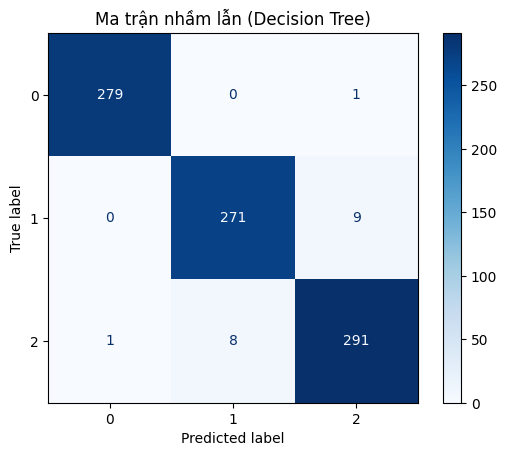

--- Huấn luyện và Đánh giá Random Forest ---

Báo cáo phân loại của Random Forest trên tập kiểm tra:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       280
           1       0.97      0.98      0.98       280
           2       0.98      0.97      0.97       300

    accuracy                           0.98       860
   macro avg       0.98      0.98      0.98       860
weighted avg       0.98      0.98      0.98       860


Ma trận nhầm lẫn của Random Forest trên tập kiểm tra:


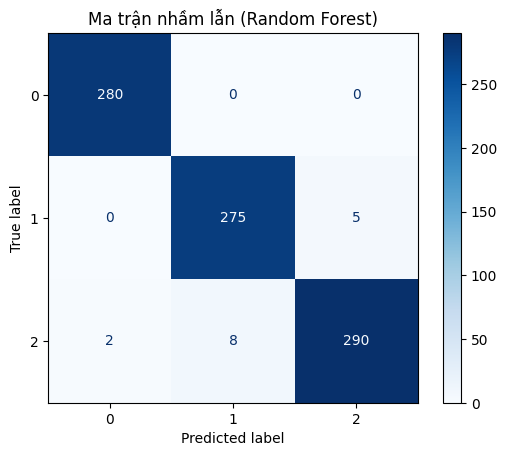

--- Huấn luyện và Đánh giá KNN ---

Báo cáo phân loại của KNN trên tập kiểm tra:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       280
           1       0.80      0.97      0.88       280
           2       0.96      0.70      0.81       300

    accuracy                           0.89       860
   macro avg       0.90      0.89      0.88       860
weighted avg       0.90      0.89      0.88       860


Ma trận nhầm lẫn của KNN trên tập kiểm tra:


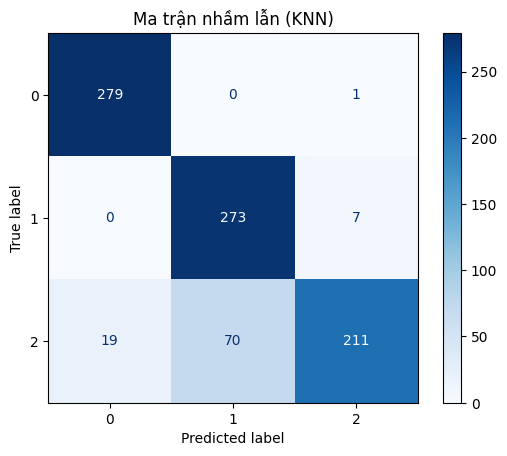

In [41]:
# ## **Huấn luyện và Đánh giá các Mô hình Ứng viên**

# Huấn luyện và đánh giá hiệu suất ban đầu của một số mô hình phân loại khác nhau để tìm ra mô hình triển vọng.

# Import các thư viện cần thiết cho các mô hình
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn nếu chưa có

# --- Huấn luyện và Đánh giá Decision Tree ---
print("--- Huấn luyện và Đánh giá Decision Tree ---")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("\nBáo cáo phân loại của Decision Tree trên tập kiểm tra:")
print(classification_report(y_test, y_pred_dt))

print("\nMa trận nhầm lẫn của Decision Tree trên tập kiểm tra:")
ConfusionMatrixDisplay.from_estimator(dt_model, X_test, y_test, cmap='Blues')
plt.title("Ma trận nhầm lẫn (Decision Tree)")
plt.show()

# --- Huấn luyện và Đánh giá Random Forest ---
print("--- Huấn luyện và Đánh giá Random Forest ---")
# Sử dụng Random Forest với siêu tham số mặc định (hoặc giá trị khởi tạo) để đánh giá ban đầu
rf_model_initial = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_initial.fit(X_train, y_train)
y_pred_rf_initial = rf_model_initial.predict(X_test)

print("\nBáo cáo phân loại của Random Forest trên tập kiểm tra:")
print(classification_report(y_test, y_pred_rf_initial))

print("\nMa trận nhầm lẫn của Random Forest trên tập kiểm tra:")
ConfusionMatrixDisplay.from_estimator(rf_model_initial, X_test, y_test, cmap='Blues')
plt.title("Ma trận nhầm lẫn (Random Forest)")
plt.show()

# --- Huấn luyện và Đánh giá KNN ---
print("--- Huấn luyện và Đánh giá KNN ---")
# Sử dụng KNN với một giá trị n_neighbors khởi tạo (ví dụ n=5)
knn_model = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='euclidean')
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("\nBáo cáo phân loại của KNN trên tập kiểm tra:")
print(classification_report(y_test, y_pred_knn))

print("\nMa trận nhầm lẫn của KNN trên tập kiểm tra:")
ConfusionMatrixDisplay.from_estimator(knn_model, X_test, y_test, cmap='Blues')
plt.title("Ma trận nhầm lẫn (KNN)")
plt.show()

## **Lựa chọn mô hình**

Bảng so sánh hiệu suất ban đầu của các mô hình:


,accuracy,macro avg
Decision Tree,0.977907,0.978134
Random Forest,0.982558,0.982714
KNN (n=5),0.887209,0.884968


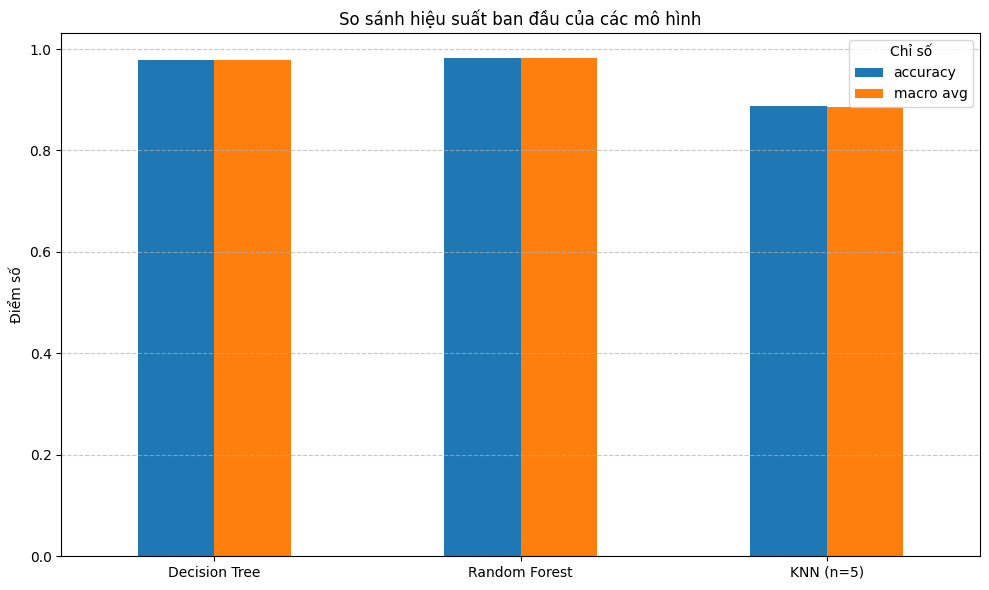

In [52]:
# ## **So sánh Hiệu suất các Mô hình Ứng viên**

# So sánh kết quả đánh giá ban đầu của các mô hình để lựa chọn mô hình triển vọng nhất cho bước điều chỉnh siêu tham số.

import pandas as pd
# Lấy các báo cáo phân loại dưới dạng dictionary
report_dt = classification_report(y_test, y_pred_dt, output_dict=True)
report_rf_initial = classification_report(y_test, y_pred_rf_initial, output_dict=True)
report_knn = classification_report(y_test, y_pred_knn, output_dict=True)


# Tạo DataFrame so sánh các chỉ số chính (ví dụ: accuracy, macro avg F1-score)
metrics_to_compare = ['accuracy', 'macro avg'] # Chọn các chỉ số bạn quan tâm

comparison_data = {
    'Decision Tree': {metric: report_dt[metric] if metric == 'accuracy' else report_dt[metric]['f1-score'] for metric in metrics_to_compare},
    'Random Forest': {metric: report_rf_initial[metric] if metric == 'accuracy' else report_rf_initial[metric]['f1-score'] for metric in metrics_to_compare},
    'KNN (n=5)': {metric: report_knn[metric] if metric == 'accuracy' else report_knn[metric]['f1-score'] for metric in metrics_to_compare}
}

comparison_df = pd.DataFrame(comparison_data).T # .T để chuyển vị DataFrame

print("Bảng so sánh hiệu suất ban đầu của các mô hình:")
display(comparison_df) # Sử dụng display trong Colab để hiển thị DataFrame đẹp hơn

# Vẽ biểu đồ so sánh
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.plot(kind='bar', ax=ax)

plt.title('So sánh hiệu suất ban đầu của các mô hình')
plt.ylabel('Điểm số')
plt.xticks(rotation=0)
plt.legend(title='Chỉ số')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Điều chỉnh mô hình**

Bắt đầu tìm kiếm siêu tham số tốt nhất cho mô hình đã chọn...

Các siêu tham số tốt nhất tìm được:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}

Điểm F1-macro tốt nhất trên tập huấn luyện (qua CV):
0.9812985612476343

Đã xác định mô hình tốt nhất sau điều chỉnh siêu tham số.
Huấn luyện mô hình cuối cùng trên tập huấn luyện...
Hoàn tất huấn luyện mô hình cuối cùng.
--- Đánh giá Hiệu suất Cuối cùng trên Tập Kiểm tra ---

Báo cáo phân loại của mô hình cuối cùng trên tập kiểm tra:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       280
           1       0.97      0.99      0.98       280
           2       0.99      0.97      0.98       300

    accuracy                           0.98       860
   macro avg       0.98      0.99      0.99       860
weighted avg       0.98      0.98      0.98       860


Ma trận nhầm lẫn của mô hình cuối cùng trên tập kiểm tra:


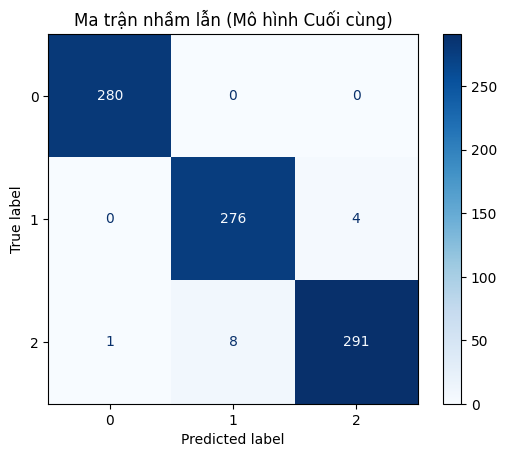

In [53]:
from sklearn.model_selection import GridSearchCV

model_to_tune = RandomForestClassifier(random_state=42) # Khởi tạo lại mô hình để tuning

# Định nghĩa không gian siêu tham số cần tìm kiếm
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Khởi tạo GridSearchCV
# cv=5: 5-fold cross-validation
# scoring='f1_macro': Sử dụng F1-macro score cho bài toán mất cân bằng lớp (tùy chọn score phù hợp)
# n_jobs=-1: Sử dụng tất cả các core CPU có sẵn
grid_search = GridSearchCV(estimator=model_to_tune, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1)

# Thực hiện tìm kiếm trên tập huấn luyện
print("Bắt đầu tìm kiếm siêu tham số tốt nhất cho mô hình đã chọn...")
grid_search.fit(X_train, y_train)

# In ra kết quả tìm kiếm
print("\nCác siêu tham số tốt nhất tìm được:")
print(grid_search.best_params_)
print("\nĐiểm F1-macro tốt nhất trên tập huấn luyện (qua CV):")
print(grid_search.best_score_)

# Lấy mô hình tốt nhất sau khi tìm kiếm
best_tuned_model = grid_search.best_estimator_
print("\nĐã xác định mô hình tốt nhất sau điều chỉnh siêu tham số.")


# ## **Huấn luyện Mô hình Cuối cùng**

# Huấn luyện mô hình đã chọn với bộ siêu tham số tối ưu tìm được trên toàn bộ tập huấn luyện.

# Mô hình cuối cùng là mô hình tốt nhất từ GridSearchCV
final_model = best_tuned_model

# Huấn luyện mô hình cuối cùng trên toàn bộ tập huấn luyện
print("Huấn luyện mô hình cuối cùng trên tập huấn luyện...")

final_model.fit(X_train, y_train)
print("Hoàn tất huấn luyện mô hình cuối cùng.")


# ## **Đánh giá Hiệu suất Cuối cùng**

# Đánh giá hiệu suất của mô hình cuối cùng đã được điều chỉnh siêu tham số trên tập kiểm tra chưa sử dụng trong quá trình điều chỉnh.

# Đánh giá mô hình cuối cùng trên tập kiểm tra
print("--- Đánh giá Hiệu suất Cuối cùng trên Tập Kiểm tra ---")
y_pred_final = final_model.predict(X_test)

# In báo cáo phân loại chi tiết
print("\nBáo cáo phân loại của mô hình cuối cùng trên tập kiểm tra:")
print(classification_report(y_test, y_pred_final))

# Vẽ Ma trận nhầm lẫn
print("\nMa trận nhầm lẫn của mô hình cuối cùng trên tập kiểm tra:")
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test, cmap='Blues')
plt.title("Ma trận nhầm lẫn (Mô hình Cuối cùng)")
plt.show()

In [54]:


from sklearn.metrics import accuracy_score
# Tính độ chính xác trên tập kiểm tra
accuracy = accuracy_score(y_test, y_pred_final)

# In độ chính xác với 6 số thập phân
print(f"Độ chính xác của mô hình cuối cùng trên tập kiểm tra: {accuracy:.6f}")


Độ chính xác của mô hình cuối cùng trên tập kiểm tra: 0.984884


In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final, digits=4))


              precision    recall  f1-score   support

           0     0.9964    1.0000    0.9982       280
           1     0.9718    0.9857    0.9787       280
           2     0.9864    0.9700    0.9782       300

    accuracy                         0.9849       860
   macro avg     0.9849    0.9852    0.9850       860
weighted avg     0.9849    0.9849    0.9849       860



## **Triển khai và sử dụng**

In [56]:

# ## **Dự đoán trên Dữ liệu Mới**

import pandas as pd
import numpy as np

new_data_raw = {
    'Temp': [32.805399, 22.1, 31.0, 28.5, 25.0],
    'Turbidity (cm)': [20.676184, 8.9, 25.5, 15.0, 10.0],
    'DO(mg/L)': [7.378096, 8.2, 3.1, 6.5, 7.8],
    'BOD (mg/L)': [3.053284, 1.5, 7.8, 4.0, 2.5],
    'CO2': [2.715065, 2.1, 9.0, 3.5, 1.8],
    'pH`': [9.130834, 6.8, 8.8, 7.5, 7.2],
    'Alkalinity (mg L-1 )': [156.458673, 80.0, 180.0, 120.0, 100.0],
    'Hardness (mg L-1 )': [55.577111, 90.0, 250.0, 100.0, 80.0],
    'Calcium (mg L-1 )': [21.187098, 30.0, 100.0, 40.0, 35.0],
    'Ammonia (mg L-1 )': [0.043464, 0.005, 0.5, 0.02, 0.01],
    'Nitrite (mg L-1 )': [0.532630, 0.01, 1.2, 0.1, 0.03],
    'Phosphorus (mg L-1 )': [0.021368, 0.05, 0.8, 0.08, 0.04],
    'H2S (mg L-1 )': [0.014266, 0.0005, 0.05, 0.002, 0.001],
    'Plankton (No. L-1)': [5441.194883, 800.0, 5000.0, 2000.0, 1500.0]
}

new_df = pd.DataFrame(new_data_raw)

print("Dữ liệu mới ban đầu:")
print(new_df)

# --- Áp dụng các bước tiền xử lý GIỐNG HỆT như trên tập huấn luyện ban đầu ---
# Lưu ý: Sử dụng CÁC THỐNG KÊ (trung vị điền thiếu, giới hạn winsorizing, scaler) được học từ tập huấn luyện

# 1. Xử lý dữ liệu thiếu (nếu dữ liệu mới có thiếu, áp dụng trung vị từ tập train)
new_df.fillna(new_df.median(), inplace=True)

# 2. Xử lý Outlier (Winsorizing)
columns_to_winsorize = [
    'Temp', 'CO2', 'pH`', 'Hardness (mg L-1 )', 'Calcium (mg L-1 )',
    'H2S (mg L-1 )', 'Plankton (No. L-1)'
]
from scipy.stats.mstats import winsorize

for col in columns_to_winsorize:
    if col in new_df.columns:
        try:
            # Áp dụng winsorize với giới hạn đã dùng trên tập huấn luyện
            new_df[col] = winsorize(new_df[col], limits=[0.05, 0.05]) # Sử dụng cùng giới hạn
        except Exception as e:
            print(f"Không thể Winsorize cột {col} trong dữ liệu mới: {e}")


# 3. Tạo các đặc trưng mới (phải khớp với cách làm trên X_train)
new_df['BOD_DO_Ratio'] = new_df['BOD (mg/L)'] / (new_df['DO(mg/L)'] + 1e-9)
new_df['Nitrite_Ammonia_Ratio'] = new_df['Nitrite (mg L-1 )'] / (new_df['Ammonia (mg L-1 )'] + 1e-9)
new_df['Total_Nutrients'] = new_df['Nitrite (mg L-1 )'] + new_df['Phosphorus (mg L-1 )']

# 4. Lựa chọn đặc trưng (chỉ giữ lại các đặc trưng ĐÃ CHỌN từ bước lựa chọn đặc trưng)

# Kiểm tra xem tất cả selected_features có tồn tại trong new_df sau khi tạo đặc trưng mới không
missing_selected_features = [col for col in selected_features if col not in new_df.columns]
if missing_selected_features:
    print(f"Cảnh báo: Các đặc trưng đã chọn sau đây không có trong dữ liệu mới: {missing_selected_features}")
    # Tùy chọn: Xử lý lỗi hoặc bỏ qua các đặc trưng thiếu này
    selected_features_present = [col for col in selected_features if col in new_df.columns]
else:
    selected_features_present = selected_features

# Chỉ giữ lại các đặc trưng đã chọn trong dữ liệu mới
new_df_selected = new_df[selected_features_present].copy()

print("\nDữ liệu mới sau khi áp dụng lựa chọn đặc trưng:")
print(new_df_selected)

# 6. Chuẩn hóa dữ liệu mới bằng scaler ĐÃ FIT trên X_train
# Cần sử dụng scaler đã được fit trên X_train ở bước Chuẩn hóa dữ liệu


# Chuẩn hóa dữ liệu mới đã chọn đặc trưng
new_data_scaled = scaler.transform(new_df_selected)

print("\nDữ liệu mới sau khi chuẩn hóa:")
print(new_data_scaled[:5]) # In ra vài dòng đầu tiên của mảng numpy đã chuẩn hóa

# --- Dự đoán bằng mô hình cuối cùng ---
# Cần sử dụng final_model (mô hình đã được huấn luyện cuối cùng)


new_predictions = final_model.predict(new_data_scaled)

# Chuyển kết quả dự đoán thành nhãn chất lượng nước dễ hiểu
label_map_reverse = {0: "Kém", 1: "Tốt", 2: "Xuất sắc"}
predicted_quality = [label_map_reverse[pred] for pred in new_predictions]

# In kết quả dự đoán
print("\nDự đoán chất lượng nước cho dữ liệu mới:")
for i, pred in enumerate(predicted_quality):
  print(f"Mẫu {i+1}: {pred}")

# Tùy chọn: Hiển thị dữ liệu mới gốc cùng với dự đoán
new_df_with_pred = new_data_raw.copy() # Sử dụng dữ liệu gốc để hiển thị
new_df_with_pred['Predicted Quality'] = predicted_quality
print("\nDữ liệu mới gốc với kết quả dự đoán:")
print(pd.DataFrame(new_df_with_pred))



Dữ liệu mới ban đầu:
        Temp  Turbidity (cm)  DO(mg/L)  BOD (mg/L)       CO2       pH`  \
0  32.805399       20.676184  7.378096    3.053284  2.715065  9.130834   
1  22.100000        8.900000  8.200000    1.500000  2.100000  6.800000   
2  31.000000       25.500000  3.100000    7.800000  9.000000  8.800000   
3  28.500000       15.000000  6.500000    4.000000  3.500000  7.500000   
4  25.000000       10.000000  7.800000    2.500000  1.800000  7.200000   

   Alkalinity (mg L-1 )  Hardness (mg L-1 )  Calcium (mg L-1 )  \
0            156.458673           55.577111          21.187098   
1             80.000000           90.000000          30.000000   
2            180.000000          250.000000         100.000000   
3            120.000000          100.000000          40.000000   
4            100.000000           80.000000          35.000000   

   Ammonia (mg L-1 )  Nitrite (mg L-1 )  Phosphorus (mg L-1 )  H2S (mg L-1 )  \
0           0.043464            0.53263              0.02